<a href="https://colab.research.google.com/github/chadnar2/WindTurbine/blob/main/custom_INN_ReneWind_Main_Project_FullCode_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Problem Statement**

## Business Context

Renewable energy sources play an increasingly important role in the global energy mix, as the effort to reduce the environmental impact of energy production increases.

Out of all the renewable energy alternatives, wind energy is one of the most developed technologies worldwide. The U.S Department of Energy has put together a guide to achieving operational efficiency using predictive maintenance practices.

Predictive maintenance uses sensor information and analysis methods to measure and predict degradation and future component capability. The idea behind predictive maintenance is that failure patterns are predictable and if component failure can be predicted accurately and the component is replaced before it fails, the costs of operation and maintenance will be much lower.

The sensors fitted across different machines involved in the process of energy generation collect data related to various environmental factors (temperature, humidity, wind speed, etc.) and additional features related to various parts of the wind turbine (gearbox, tower, blades, break, etc.).

## Objective

“ReneWind” is a company working on improving the machinery/processes involved in the production of wind energy using machine learning and has collected data of generator failure of wind turbines using sensors. They have shared a ciphered version of the data, as the data collected through sensors is confidential (the type of data collected varies with companies). Data has 40 predictors, 20000 observations in the training set and 5000 in the test set.

The objective is to build various classification models, tune them, and find the best one that will help identify failures so that the generators could be repaired before failing/breaking to reduce the overall maintenance cost.
The nature of predictions made by the classification model will translate as follows:

- True positives (TP) are failures correctly predicted by the model. These will result in repairing costs.
- False negatives (FN) are real failures where there is no detection by the model. These will result in replacement costs.
- False positives (FP) are detections where there is no failure. These will result in inspection costs.

It is given that the cost of repairing a generator is much less than the cost of replacing it, and the cost of inspection is less than the cost of repair.

“1” in the target variables should be considered as “failure” and “0” represents “No failure”.

## Data Description

The data provided is a transformed version of the original data which was collected using sensors.

- Train.csv - To be used for training and tuning of models.
- Test.csv - To be used only for testing the performance of the final best model.

Both the datasets consist of 40 predictor variables and 1 target variable.

# **Installing and Importing the necessary libraries**

In [ ]:
# Installing the libraries with the specified version
!pip install --no-deps tensorflow==2.19.0 scikit-learn==1.6.1 matplotlib===3.10.0 seaborn==0.13.2 numpy==2.0.2 pandas==2.2.2 -q --user --no-warn-script-location

**Note**:
- After running the above cell, kindly restart the runtime (for Google Colab) or notebook kernel (for Jupyter Notebook), and run all cells sequentially from the next cell.
- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in ***this notebook***.

In [ ]:
import pandas as pd
import numpy as np
#splitting datasets into training and testing sets.ne
from sklearn.model_selection import train_test_split

#Imports a class for imputing missing values in datasets.
from sklearn.impute import SimpleImputer
#Imports the Matplotlib library for creating visualizations.

import matplotlib.pyplot as plt
# Imports the Seaborn library for statistical data visualization.
import seaborn as sns
# Time related functions.
import time
#Imports functions for evaluating the performance of machine learning models
from sklearn.metrics import f1_score,accuracy_score, recall_score, precision_score, classification_report
#Imports metrics from
from sklearn import metrics

#Imports the tensorflow,keras and layers.
import tensorflow
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout,BatchNormalization
from tensorflow.keras import backend

# to suppress unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

# **Loading the Data**

In [ ]:
# uncomment and run the following lines for Google Colab
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Project4/Train.csv")    # Import the training data
df_test = pd.read_csv("/content/drive/MyDrive/Project4/Test.csv")    # Import the test data

# **Data Overview**

## Check the shape of the dataset

In [ ]:
df.shape

(20000, 41)

So 20000 rows and 41 columns in the training dataset

In [ ]:
df_test.shape

(5000, 41)

So 5000 rows and 41 columns in the test dataset

In [ ]:
#Create copies of the training and test datasets
df_copy = df.copy()
df_test_copy = df_test.copy()

## Display initial rows of the training and test datasets

In [ ]:
# View the first 5 rows of the training data
df_copy.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V32,V33,V34,V35,V36,V37,V38,V39,V40,Target
0,-4.464606,-4.679129,3.101546,0.506130,-0.221083,-2.032511,-2.910870,0.050714,-1.522351,3.761892,...,3.059700,-1.690440,2.846296,2.235198,6.667486,0.443809,-2.369169,2.950578,-3.480324,0
1,3.365912,3.653381,0.909671,-1.367528,0.332016,2.358938,0.732600,-4.332135,0.565695,-0.101080,...,-1.795474,3.032780,-2.467514,1.894599,-2.297780,-1.731048,5.908837,-0.386345,0.616242,0
2,-3.831843,-5.824444,0.634031,-2.418815,-1.773827,1.016824,-2.098941,-3.173204,-2.081860,5.392621,...,-0.257101,0.803550,4.086219,2.292138,5.360850,0.351993,2.940021,3.839160,-4.309402,0
3,1.618098,1.888342,7.046143,-1.147285,0.083080,-1.529780,0.207309,-2.493629,0.344926,2.118578,...,-3.584425,-2.577474,1.363769,0.622714,5.550100,-1.526796,0.138853,3.101430,-1.277378,0
4,-0.111440,3.872488,-3.758361,-2.982897,3.792714,0.544960,0.205433,4.848994,-1.854920,-6.220023,...,8.265896,6.629213,-10.068689,1.222987,-3.229763,1.686909,-2.163896,-3.644622,6.510338,0


In [ ]:
#View the first 5 rows of the test data
df_test_copy.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V32,V33,V34,V35,V36,V37,V38,V39,V40,Target
0,-0.613489,-3.819640,2.202302,1.300420,-1.184929,-4.495964,-1.835817,4.722989,1.206140,-0.341909,...,2.291204,-5.411388,0.870073,0.574479,4.157191,1.428093,-10.511342,0.454664,-1.448363,0
1,0.389608,-0.512341,0.527053,-2.576776,-1.016766,2.235112,-0.441301,-4.405744,-0.332869,1.966794,...,-2.474936,2.493582,0.315165,2.059288,0.683859,-0.485452,5.128350,1.720744,-1.488235,0
2,-0.874861,-0.640632,4.084202,-1.590454,0.525855,-1.957592,-0.695367,1.347309,-1.732348,0.466500,...,-1.318888,-2.997464,0.459664,0.619774,5.631504,1.323512,-1.752154,1.808302,1.675748,0
3,0.238384,1.458607,4.014528,2.534478,1.196987,-3.117330,-0.924035,0.269493,1.322436,0.702345,...,3.517918,-3.074085,-0.284220,0.954576,3.029331,-1.367198,-3.412140,0.906000,-2.450889,0
4,5.828225,2.768260,-1.234530,2.809264,-1.641648,-1.406698,0.568643,0.965043,1.918379,-2.774855,...,1.773841,-1.501573,-2.226702,4.776830,-6.559698,-0.805551,-0.276007,-3.858207,-0.537694,0


## Check the datatypes in the dataset

In [ ]:
df_test.info() #Check the the datatypes for the training data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 41 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   V1      4995 non-null   float64
 1   V2      4994 non-null   float64
 2   V3      5000 non-null   float64
 3   V4      5000 non-null   float64
 4   V5      5000 non-null   float64
 5   V6      5000 non-null   float64
 6   V7      5000 non-null   float64
 7   V8      5000 non-null   float64
 8   V9      5000 non-null   float64
 9   V10     5000 non-null   float64
 10  V11     5000 non-null   float64
 11  V12     5000 non-null   float64
 12  V13     5000 non-null   float64
 13  V14     5000 non-null   float64
 14  V15     5000 non-null   float64
 15  V16     5000 non-null   float64
 16  V17     5000 non-null   float64
 17  V18     5000 non-null   float64
 18  V19     5000 non-null   float64
 19  V20     5000 non-null   float64
 20  V21     5000 non-null   float64
 21  V22     5000 non-null   float64
 22  

Everything is of type fload64 other than the target which is an int.

In [ ]:
#Convert the target column of training data to type float
df_test['Target'] = df_test['Target'].astype(float)

In [ ]:
#Check the datatypes of the test data
df_test_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 41 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   V1      4995 non-null   float64
 1   V2      4994 non-null   float64
 2   V3      5000 non-null   float64
 3   V4      5000 non-null   float64
 4   V5      5000 non-null   float64
 5   V6      5000 non-null   float64
 6   V7      5000 non-null   float64
 7   V8      5000 non-null   float64
 8   V9      5000 non-null   float64
 9   V10     5000 non-null   float64
 10  V11     5000 non-null   float64
 11  V12     5000 non-null   float64
 12  V13     5000 non-null   float64
 13  V14     5000 non-null   float64
 14  V15     5000 non-null   float64
 15  V16     5000 non-null   float64
 16  V17     5000 non-null   float64
 17  V18     5000 non-null   float64
 18  V19     5000 non-null   float64
 19  V20     5000 non-null   float64
 20  V21     5000 non-null   float64
 21  V22     5000 non-null   float64
 22  

In [ ]:
#Convert the target value of test data to float to correspond to other values
df_test['Target'] = df['Target'].astype(float)

## Check for duplicated values in the train and test data

In [ ]:
# let's check for duplicate values in the training data
df_copy.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
19995,False
19996,False
19997,False
19998,False


Nothing is duplicated in the training data

In [ ]:
#Check for dupolicated values in the test data
df_test_copy.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
4995,False
4996,False
4997,False
4998,False


## Check for Missing Values across training and test datasets

In [ ]:
# missing values in the training data
df_copy.isnull().sum()

,0
V1,18
V2,18
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0
V10,0


No missing values in the training dataset

In [ ]:
#Check for missing values in the test dataset
df_test_copy.isnull().sum()

,0
V1,5
V2,6
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0
V10,0


In [ ]:
## Statistical Summary of the data

In [ ]:
#The statistical summary of the numerical columns in the training data
df_copy.describe() # Statistical Summary of the train data

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V32,V33,V34,V35,V36,V37,V38,V39,V40,Target
count,19982.000000,19982.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,...,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,-0.271996,0.440430,2.484699,-0.083152,-0.053752,-0.995443,-0.879325,-0.548195,-0.016808,-0.012998,...,0.303799,0.049825,-0.462702,2.229620,1.514809,0.011316,-0.344025,0.890653,-0.875630,0.055500
std,3.441625,3.150784,3.388963,3.431595,2.104801,2.040970,1.761626,3.295756,2.160568,2.193201,...,5.500400,3.575285,3.183841,2.937102,3.800860,1.788165,3.948147,1.753054,3.012155,0.228959
min,-11.876451,-12.319951,-10.708139,-15.082052,-8.603361,-10.227147,-7.949681,-15.657561,-8.596313,-9.853957,...,-19.876502,-16.898353,-17.985094,-15.349803,-14.833178,-5.478350,-17.375002,-6.438880,-11.023935,0.000000
25%,-2.737146,-1.640674,0.206860,-2.347660,-1.535607,-2.347238,-2.030926,-2.642665,-1.494973,-1.411212,...,-3.420469,-2.242857,-2.136984,0.336191,-0.943809,-1.255819,-2.987638,-0.272250,-2.940193,0.000000
50%,-0.747917,0.471536,2.255786,-0.135241,-0.101952,-1.000515,-0.917179,-0.389085,-0.067597,0.100973,...,0.052073,-0.066249,-0.255008,2.098633,1.566526,-0.128435,-0.316849,0.919261,-0.920806,0.000000
75%,1.840112,2.543967,4.566165,2.130615,1.340480,0.380330,0.223695,1.722965,1.409203,1.477045,...,3.761722,2.255134,1.436935,4.064358,3.983939,1.175533,2.279399,2.057540,1.119897,0.000000
max,15.493002,13.089269,17.090919,13.236381,8.133797,6.975847,8.006091,11.679495,8.137580,8.108472,...,23.633187,16.692486,14.358213,15.291065,19.329576,7.467006,15.289923,7.759877,10.654265,1.000000


Values of all the variabls lie between -25 and 25.

In [ ]:
#The statistical summary of the numerical columns in the test data
df_test_copy.describe() # Statistical Summary of the train data

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V32,V33,V34,V35,V36,V37,V38,V39,V40,Target
count,4995.000000,4994.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,...,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,-0.277622,0.397928,2.551787,-0.048943,-0.080120,-1.042138,-0.907922,-0.574592,0.030121,0.018524,...,0.232567,-0.080115,-0.392663,2.211205,1.594845,0.022931,-0.405659,0.938800,-0.932406,0.056400
std,3.466280,3.139562,3.326607,3.413937,2.110870,2.005444,1.769017,3.331911,2.174139,2.145437,...,5.585628,3.538624,3.166101,2.948426,3.774970,1.785320,3.968936,1.716502,2.978193,0.230716
min,-12.381696,-10.716179,-9.237940,-14.682446,-7.711569,-8.924196,-8.124230,-12.252731,-6.785495,-8.170956,...,-17.244168,-14.903781,-14.699725,-12.260591,-12.735567,-5.079070,-15.334533,-5.451050,-10.076234,0.000000
25%,-2.743691,-1.649211,0.314931,-2.292694,-1.615238,-2.368853,-2.054259,-2.642088,-1.455712,-1.353320,...,-3.556267,-2.348121,-2.009604,0.321818,-0.866066,-1.240526,-2.984480,-0.208024,-2.986587,0.000000
50%,-0.764767,0.427369,2.260428,-0.145753,-0.131890,-1.048571,-0.939695,-0.357943,-0.079891,0.166292,...,-0.076694,-0.159713,-0.171745,2.111750,1.702964,-0.110415,-0.381162,0.959152,-1.002764,0.000000
75%,1.831313,2.444486,4.587000,2.166468,1.341197,0.307555,0.212228,1.712896,1.449548,1.511248,...,3.751857,2.099160,1.465402,4.031639,4.104409,1.237522,2.287998,2.130769,1.079738,0.000000
max,13.504352,14.079073,15.314503,12.140157,7.672835,5.067685,7.616182,10.414722,8.850720,6.598728,...,26.539391,13.323517,12.146302,13.489237,17.116122,6.809938,13.064950,7.182237,8.698460,1.000000


# **Exploratory Data Analysis**

## Univariate analysis

In [ ]:
# function to plot a boxplot and a histogram along the same scale.


def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None):
    """
    Boxplot and histogram combined
    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to show density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,                # Number of rows of the subplot grid = 2
        sharex=True,            # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )

    # creating the 2 subplots
    sns.boxplot(
        data=data,
        x=feature,
        ax=ax_box2,
        showmeans=True,
        color="violet"
    )  # boxplot will be created and a star will indicate the mean value of the column

    sns.histplot(
        data=data,
        x=feature,
        kde=kde,
        ax=ax_hist2,
        bins=bins,
        palette="winter"
    ) if bins else sns.histplot(
        data=data,
        x=feature,
        kde=kde,
        ax=ax_hist2
    )  # For histogram

    ax_hist2.axvline(data[feature].mean(), color="green", linestyle="--")   # Add mean to the histogram
    ax_hist2.axvline(data[feature].median(), color="black", linestyle="-")  # Add median to the histogram


## Variables V1 to V40

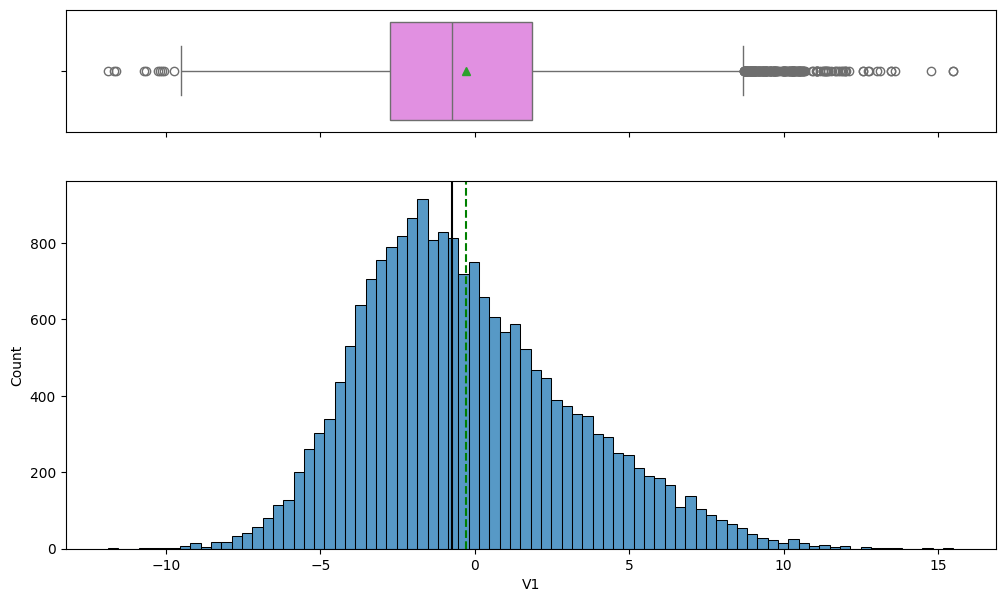

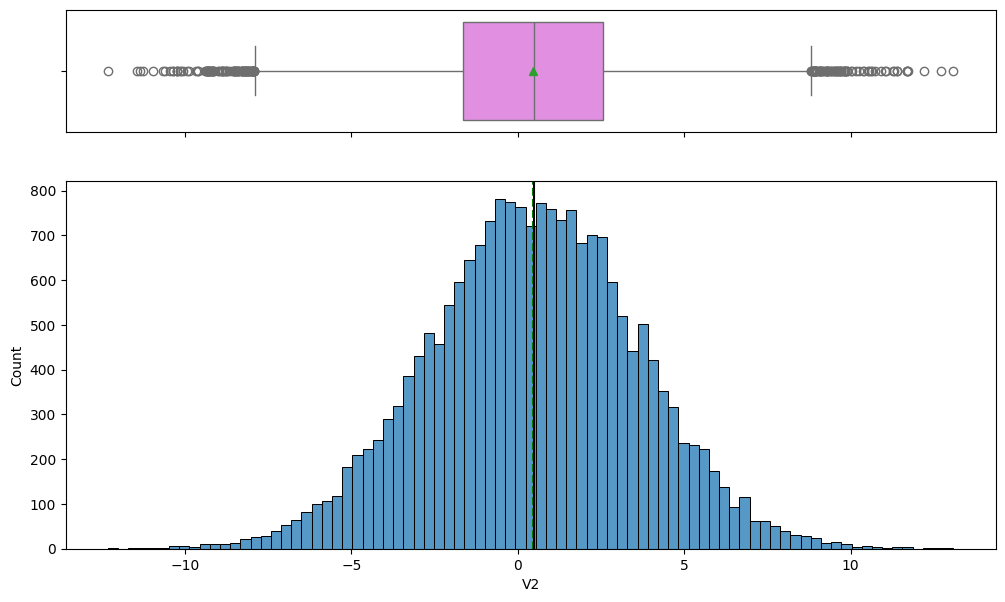

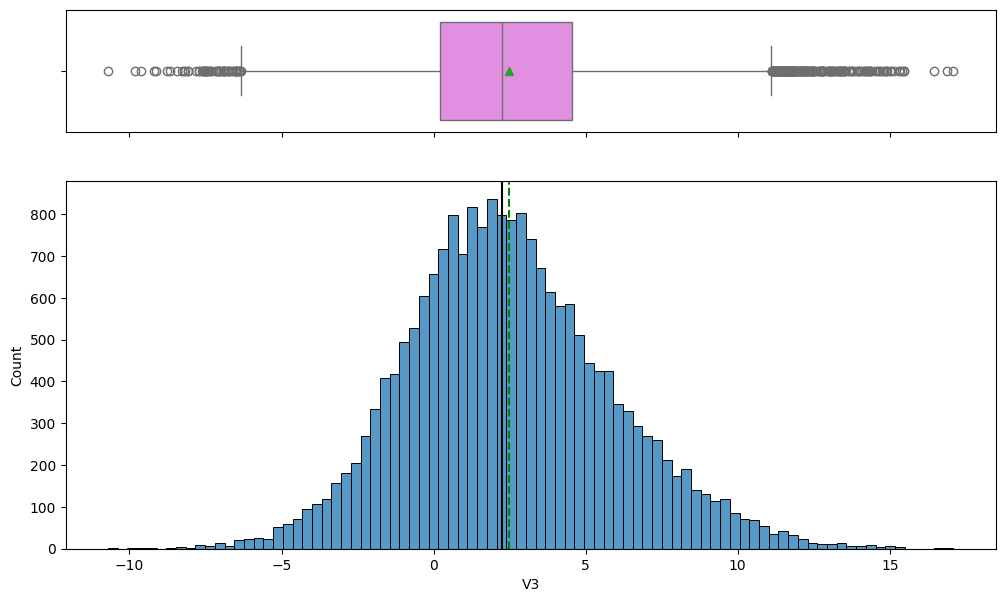

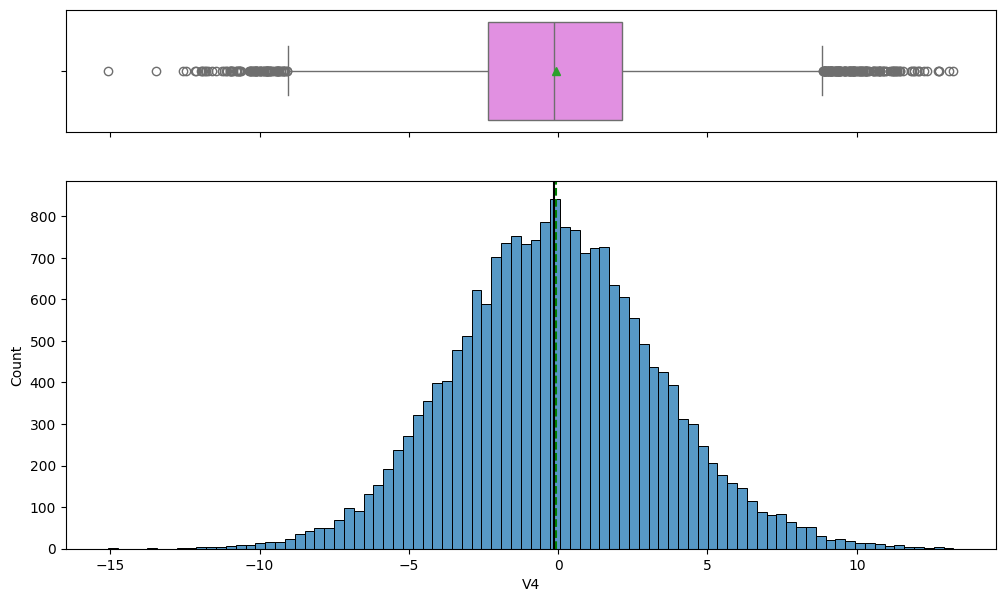

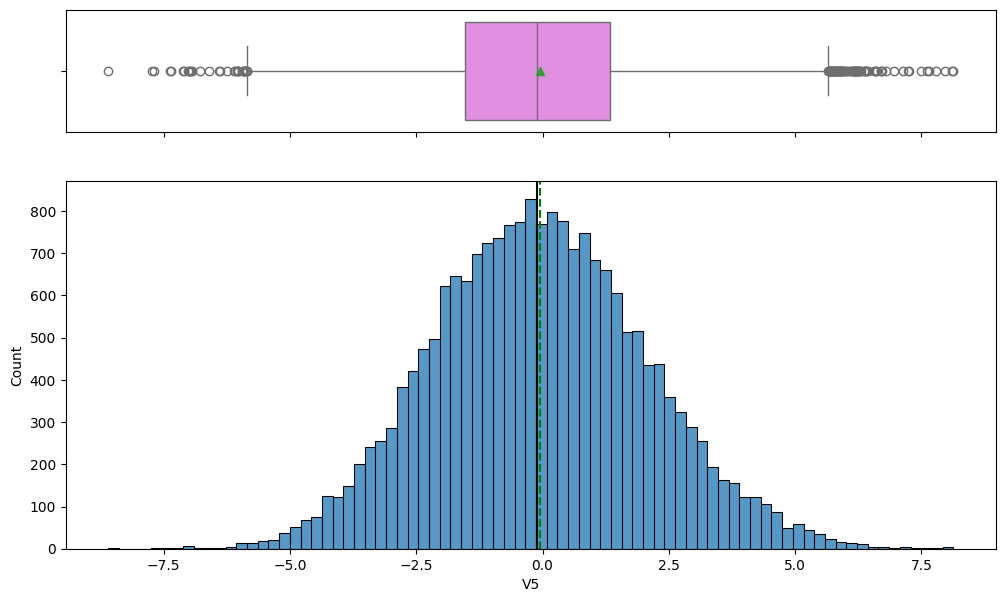

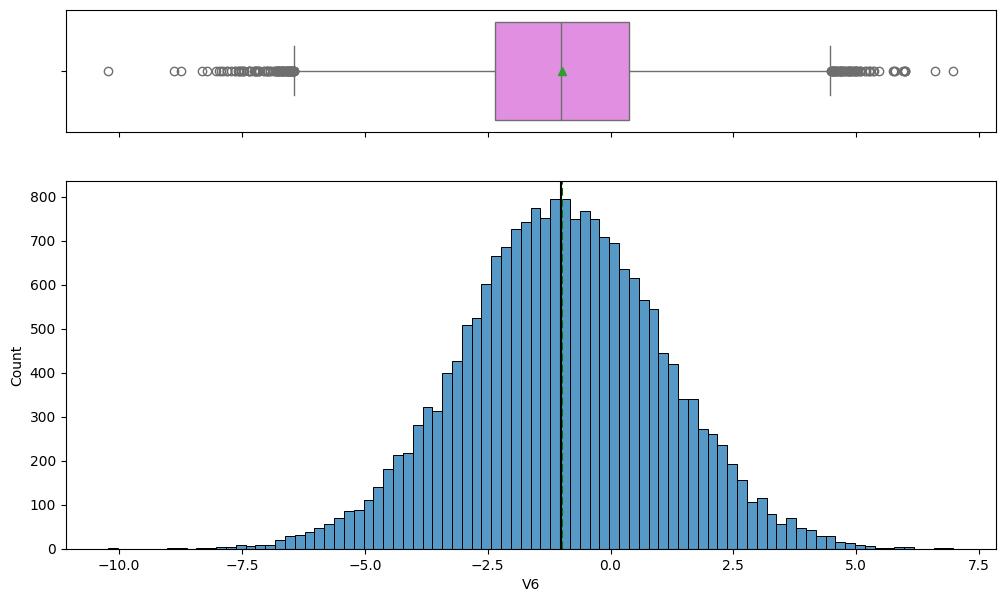

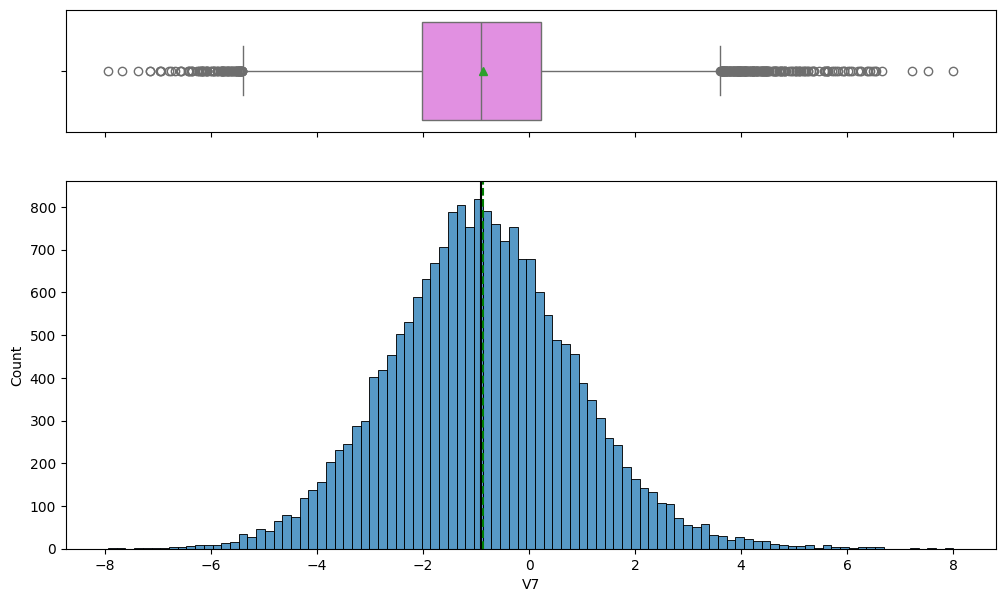

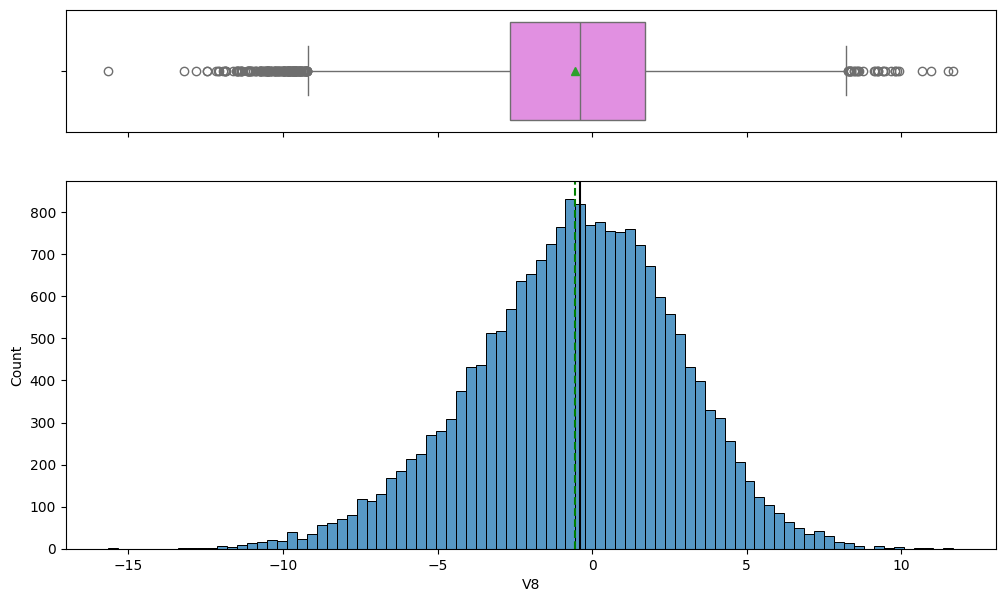

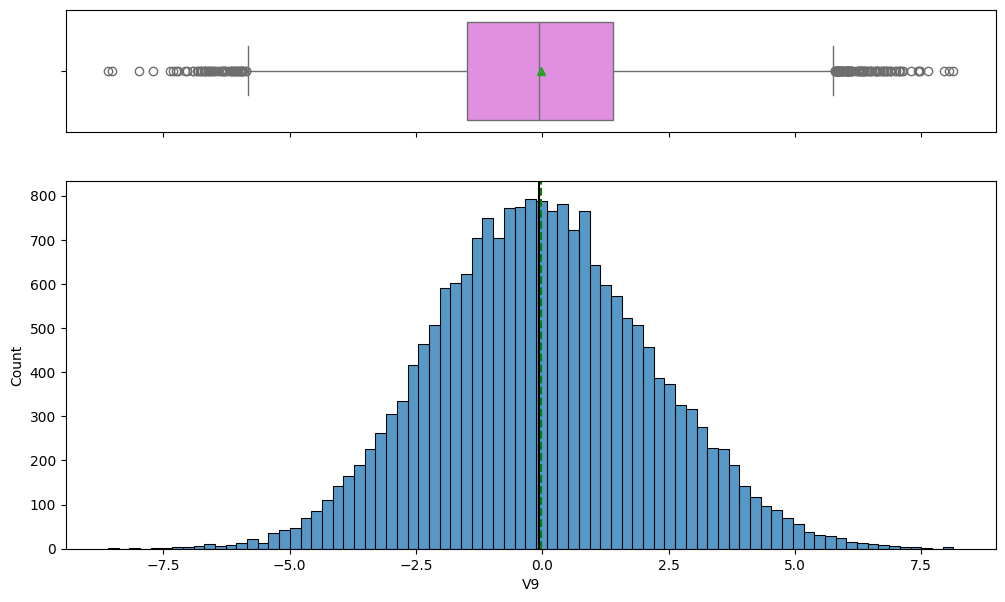

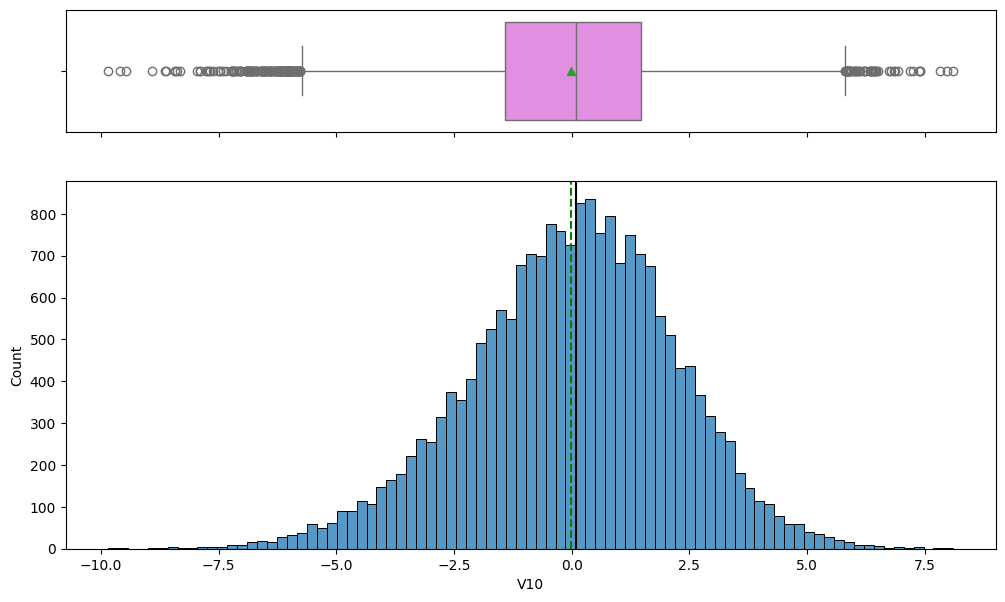

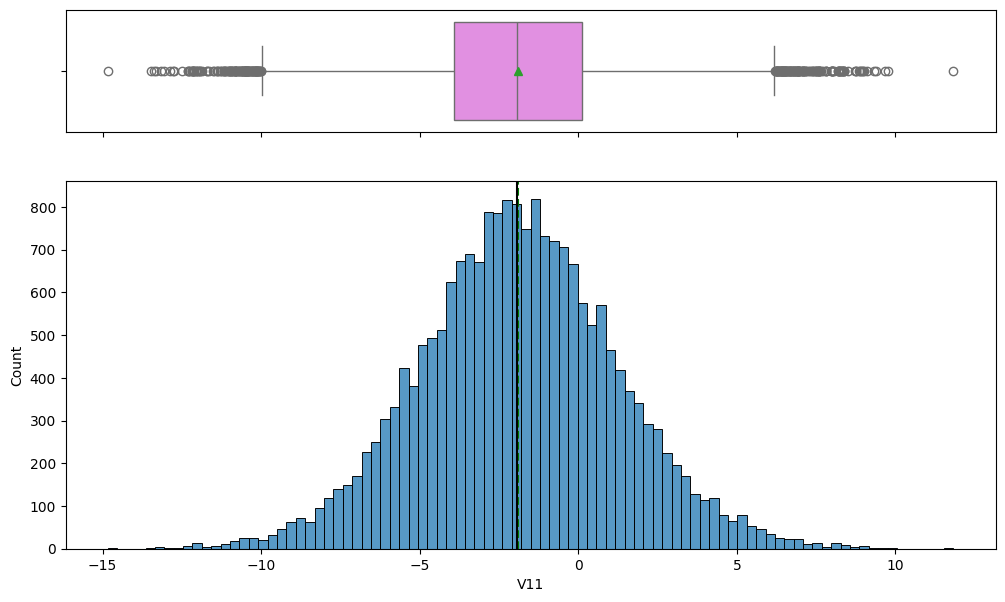

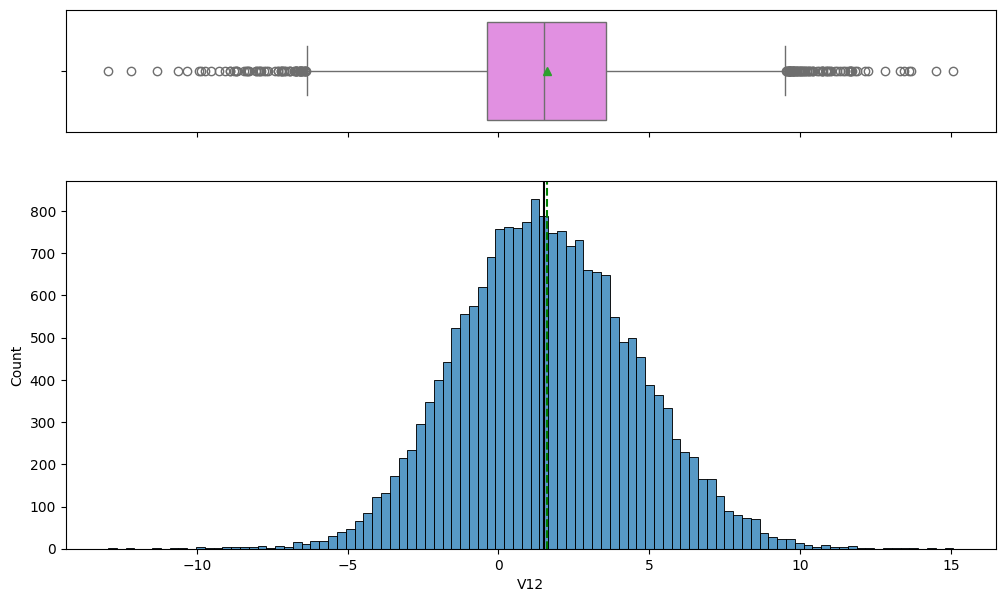

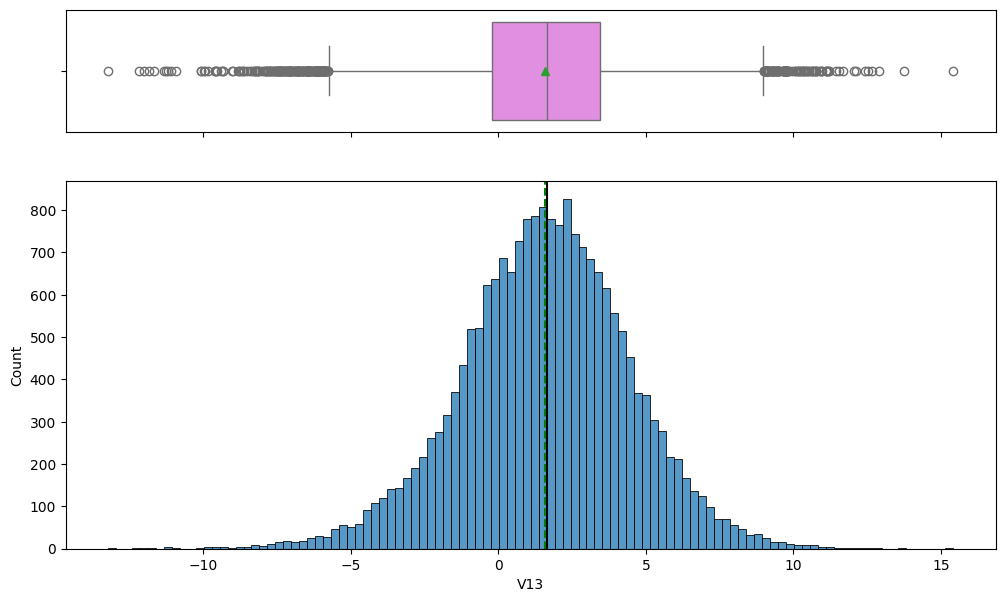

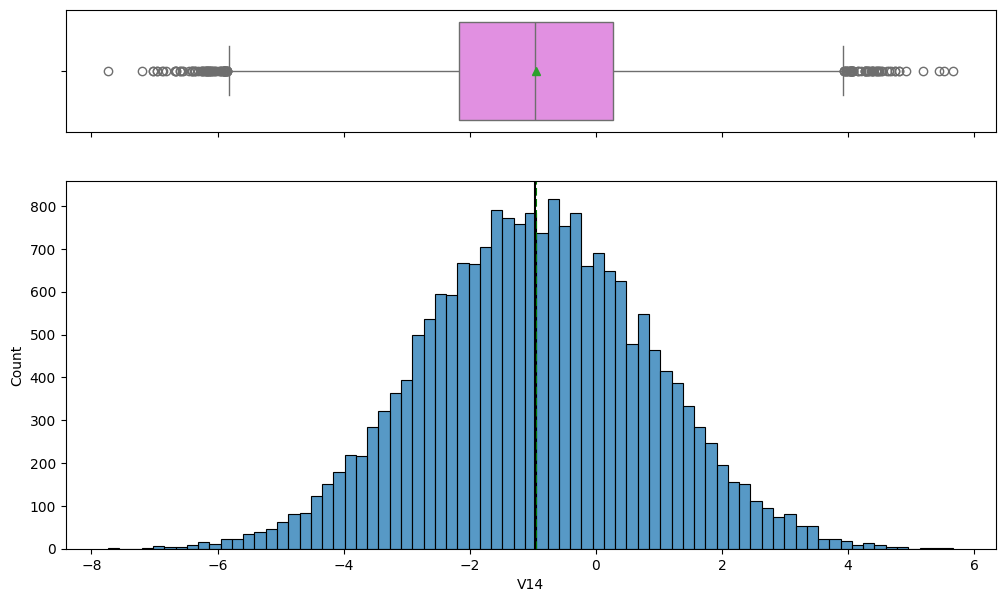

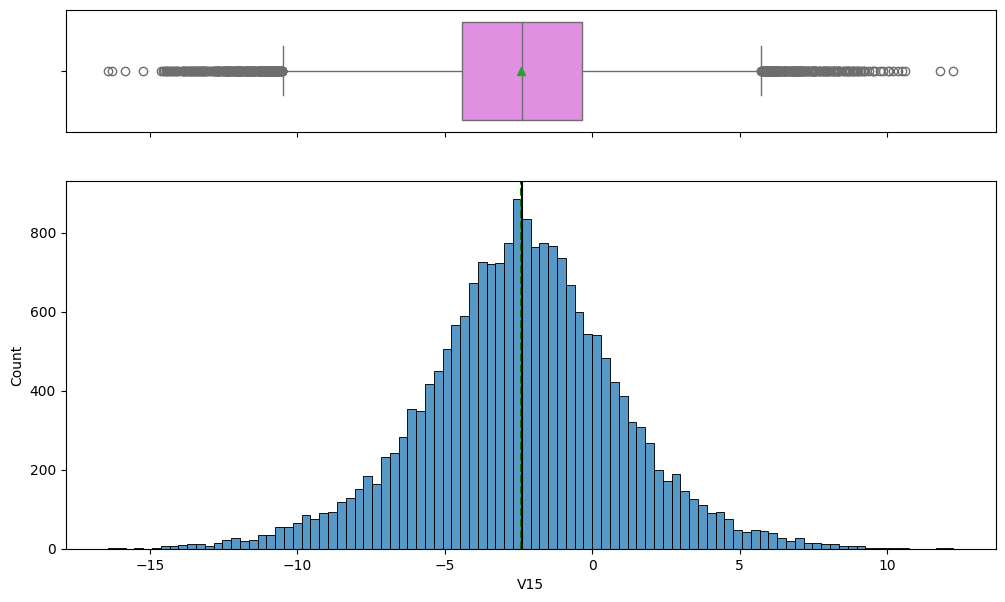

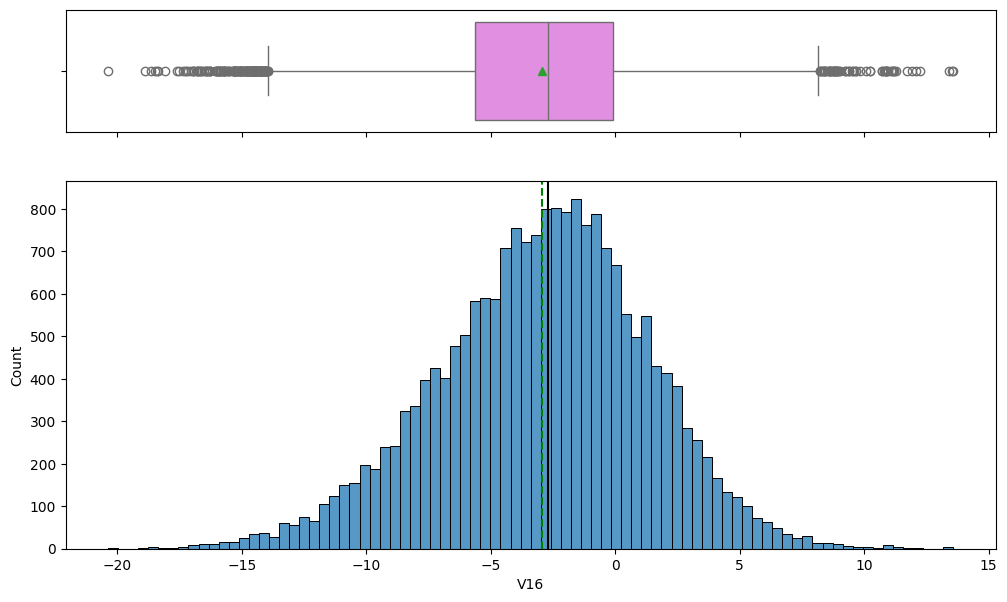

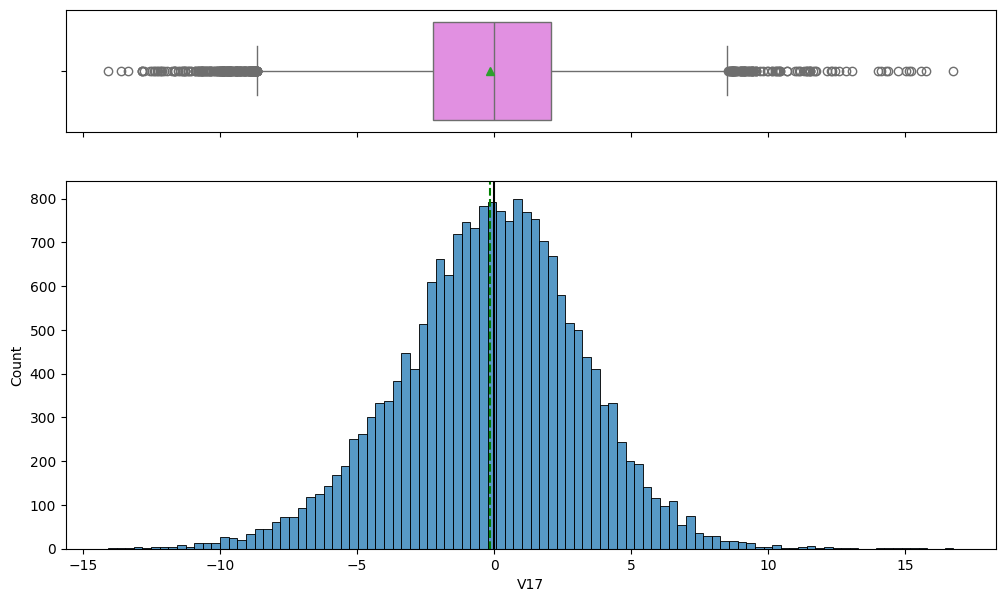

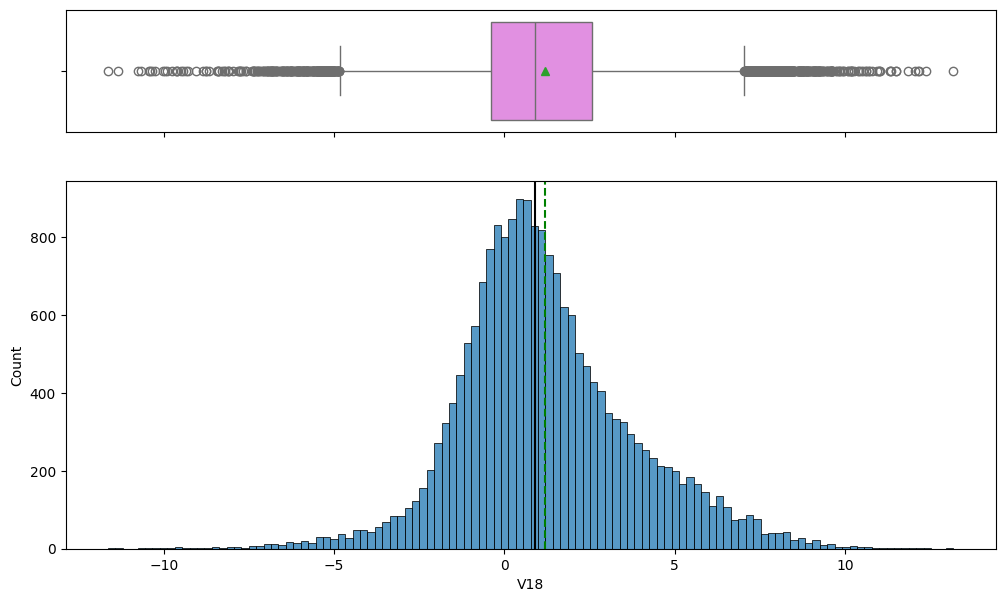

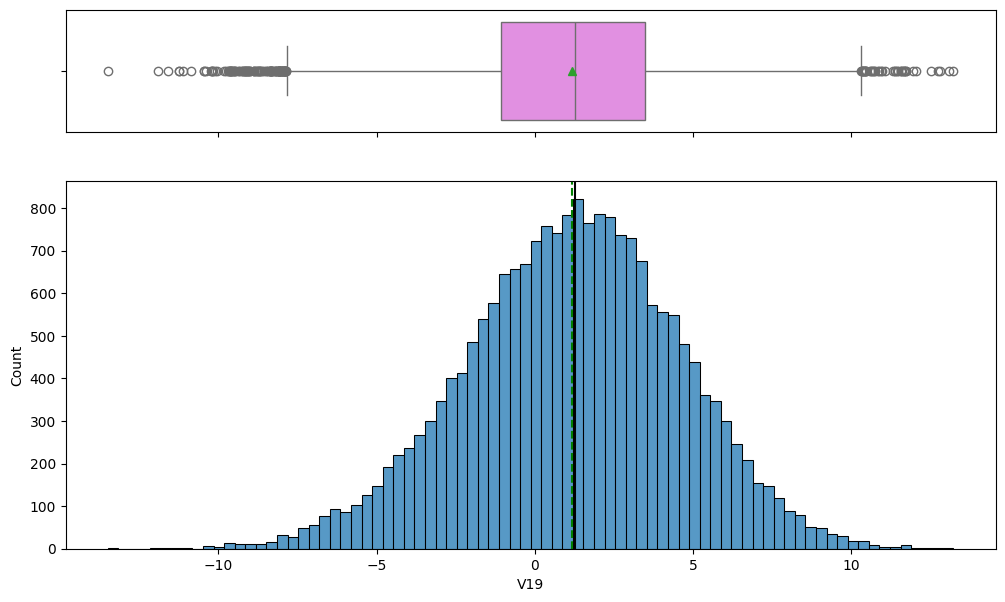

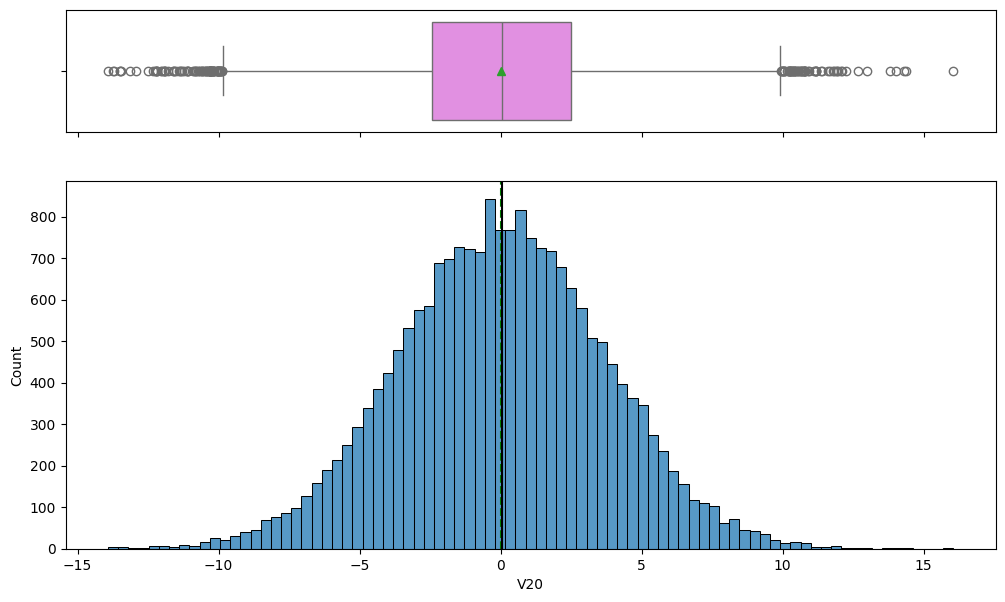

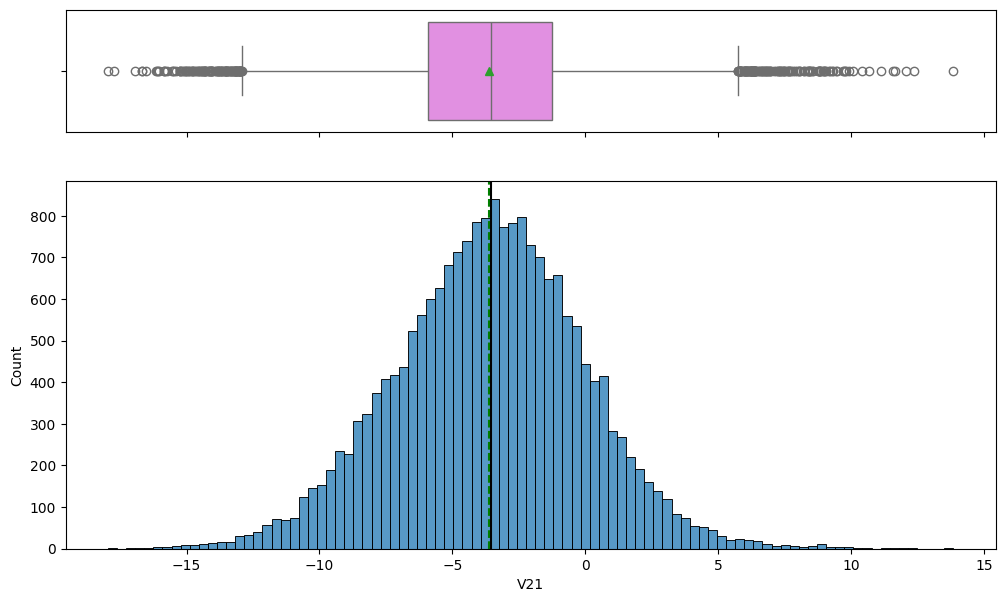

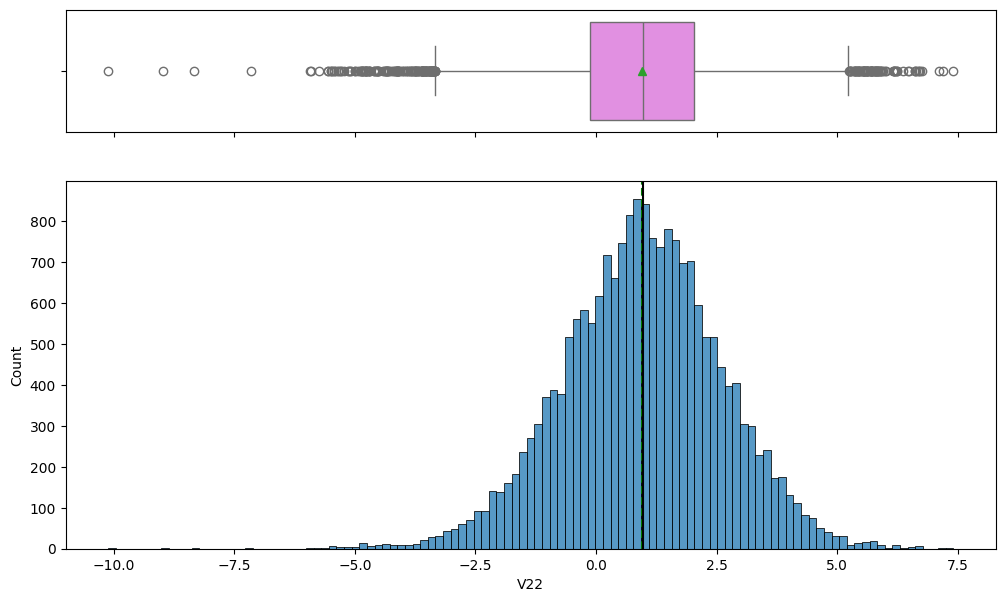

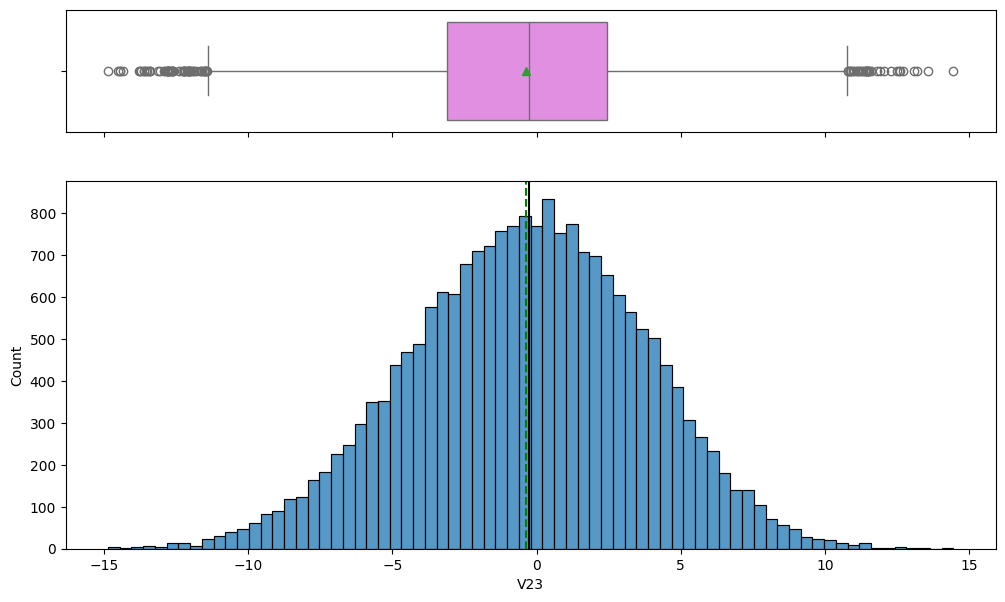

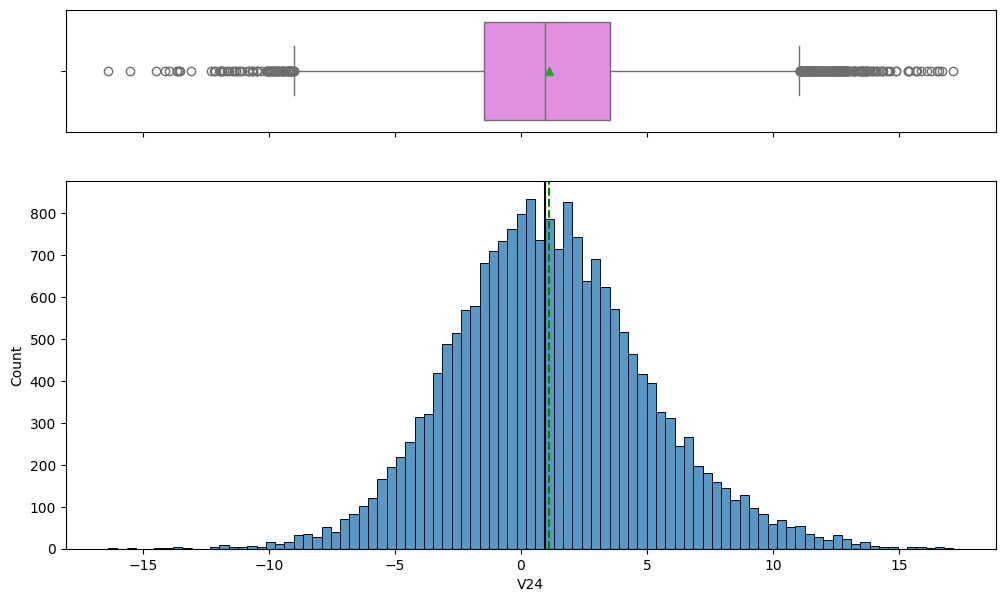

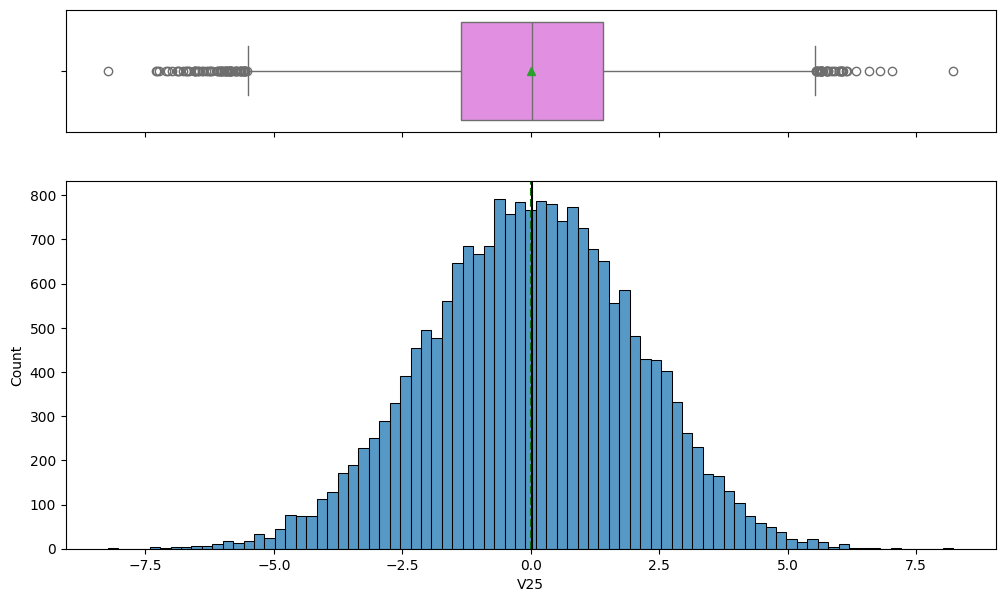

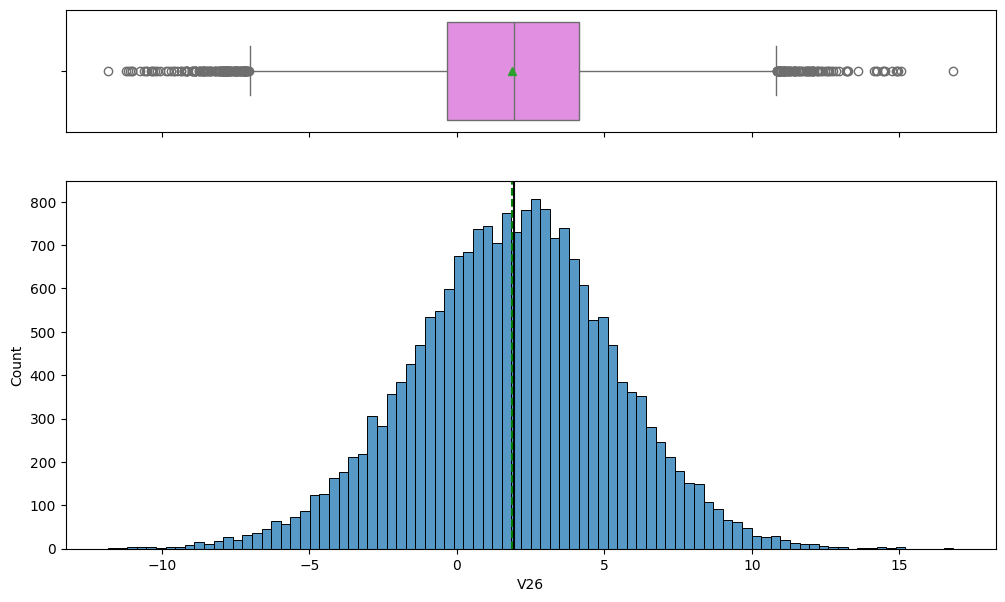

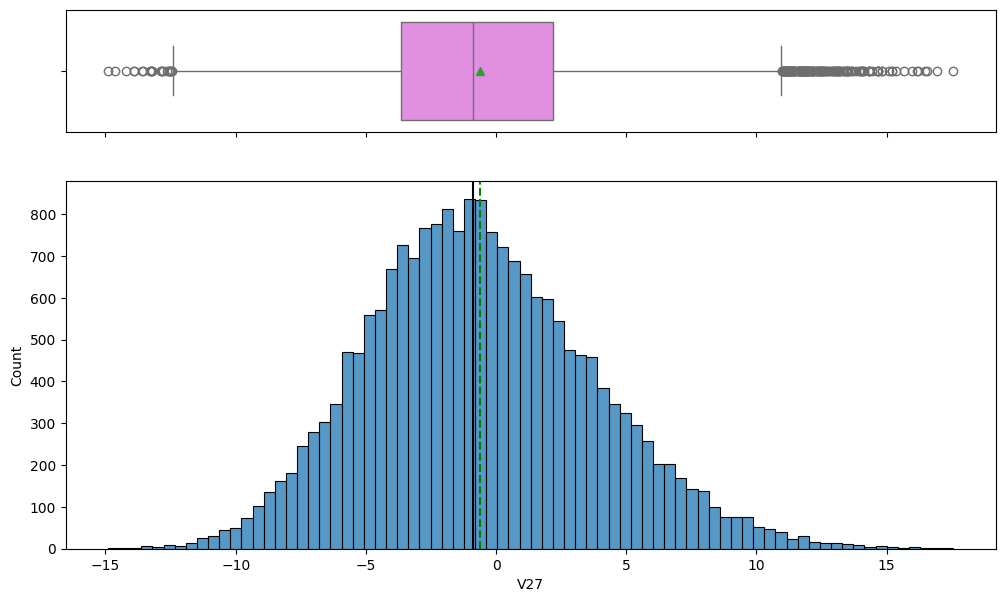

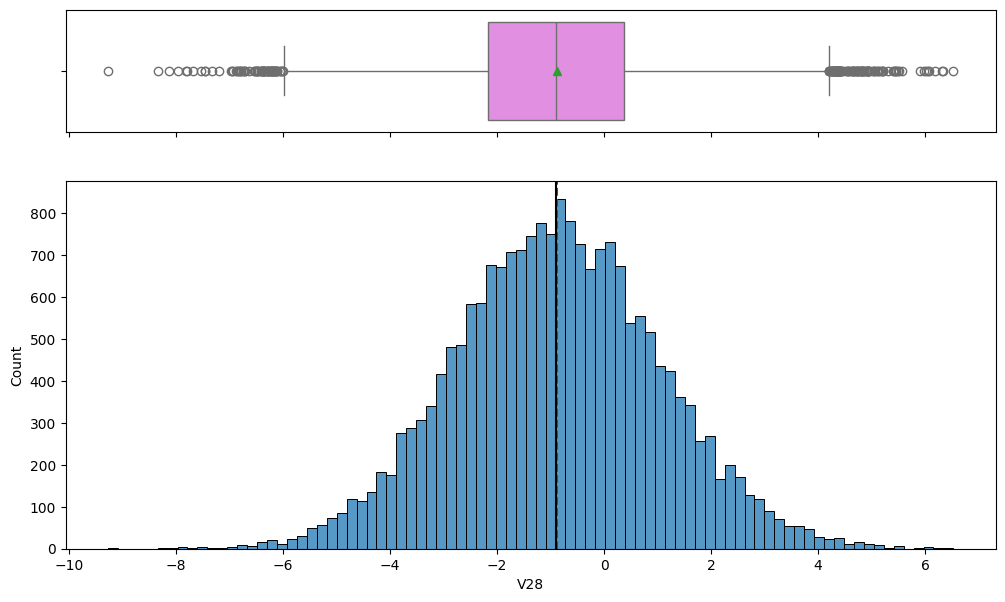

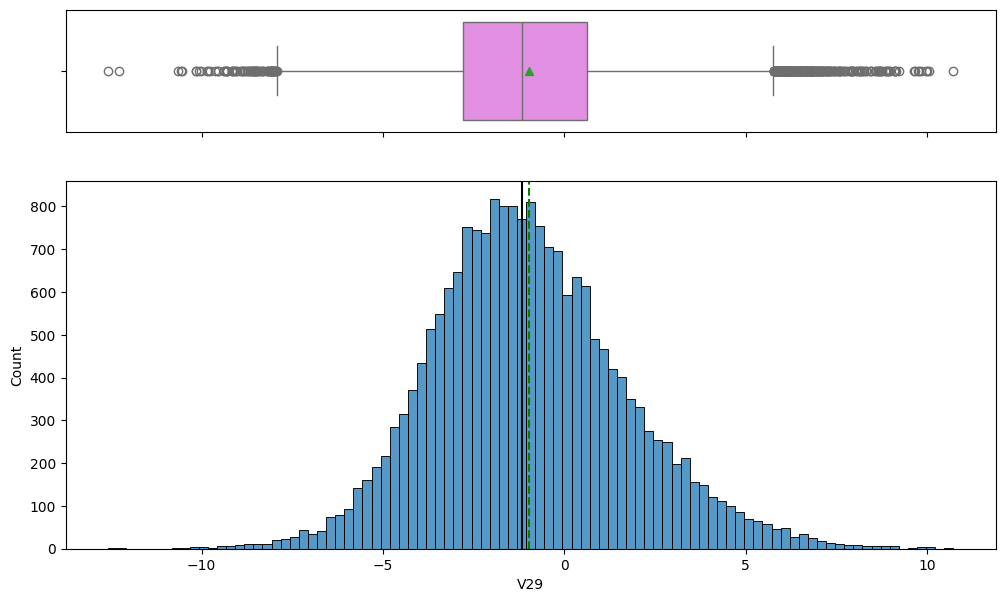

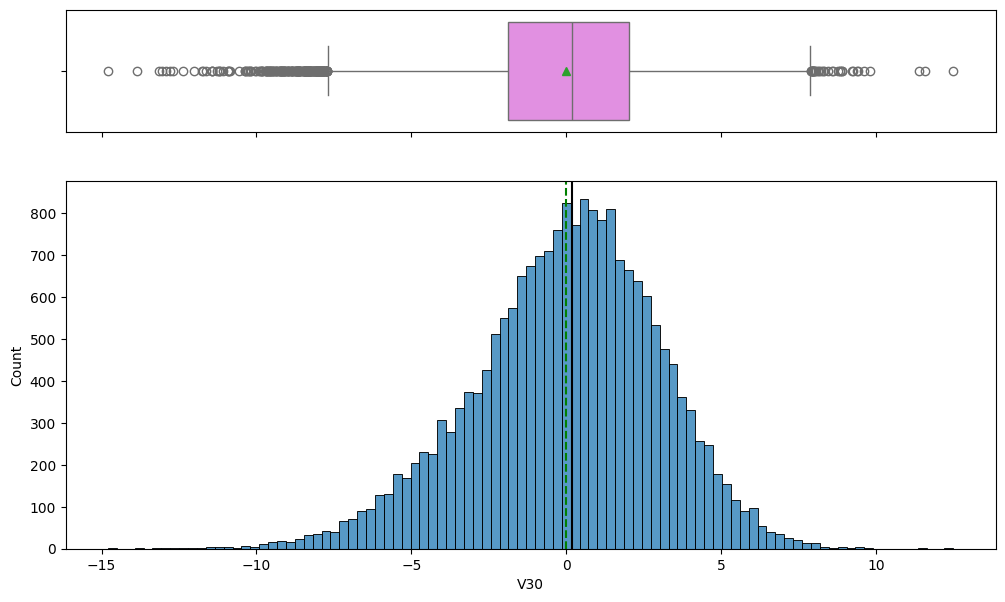

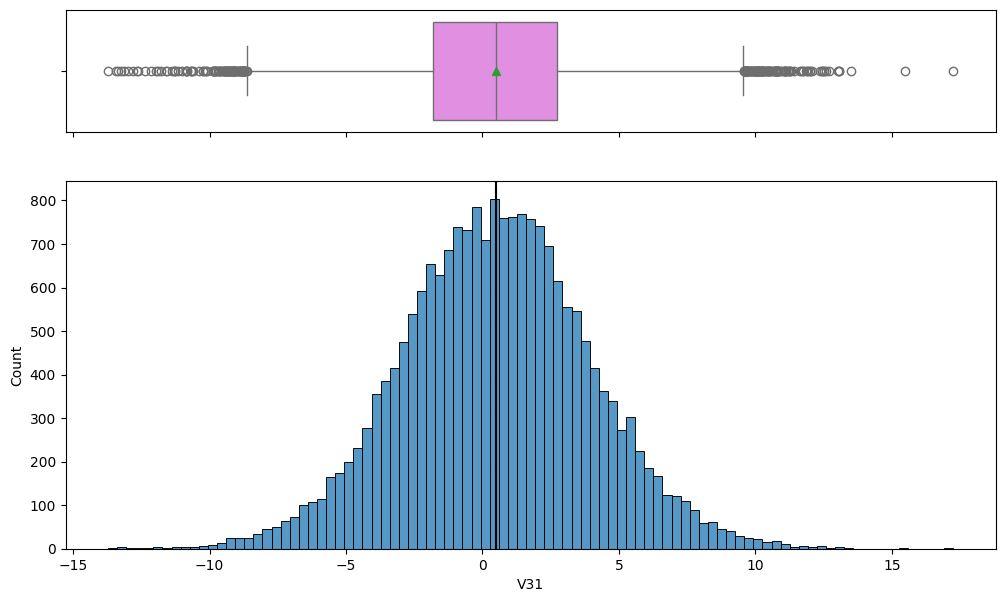

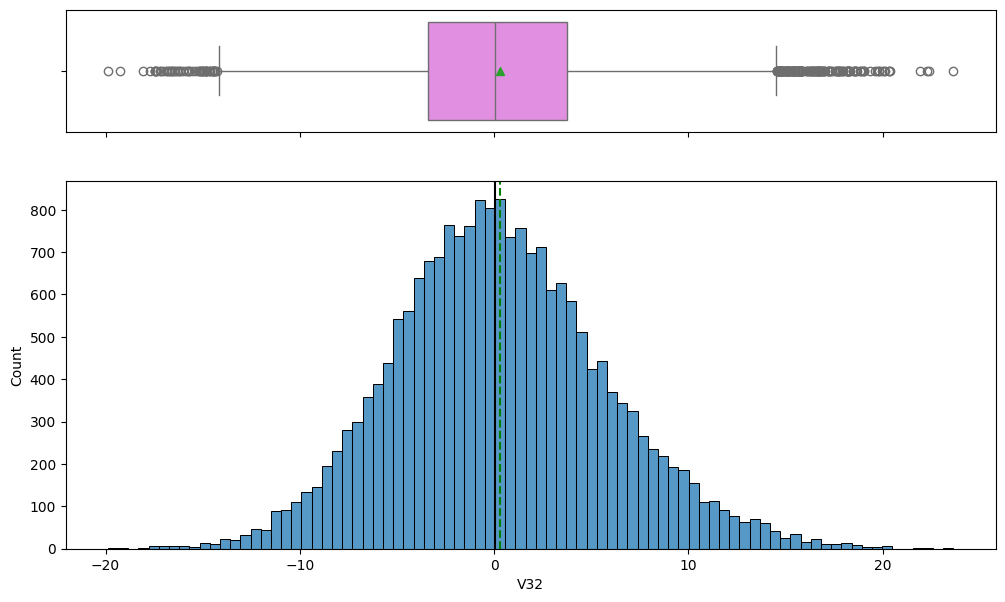

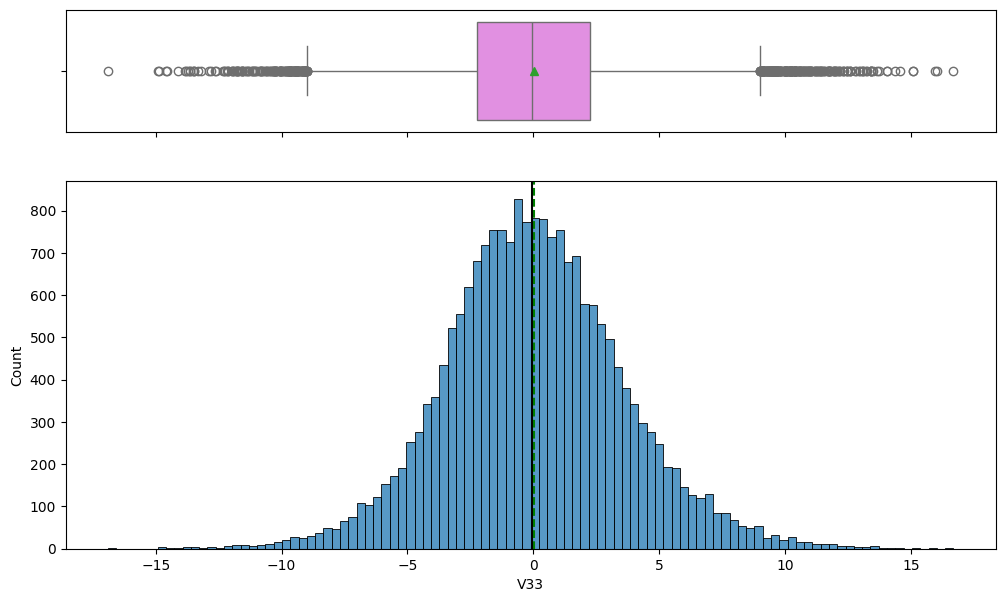

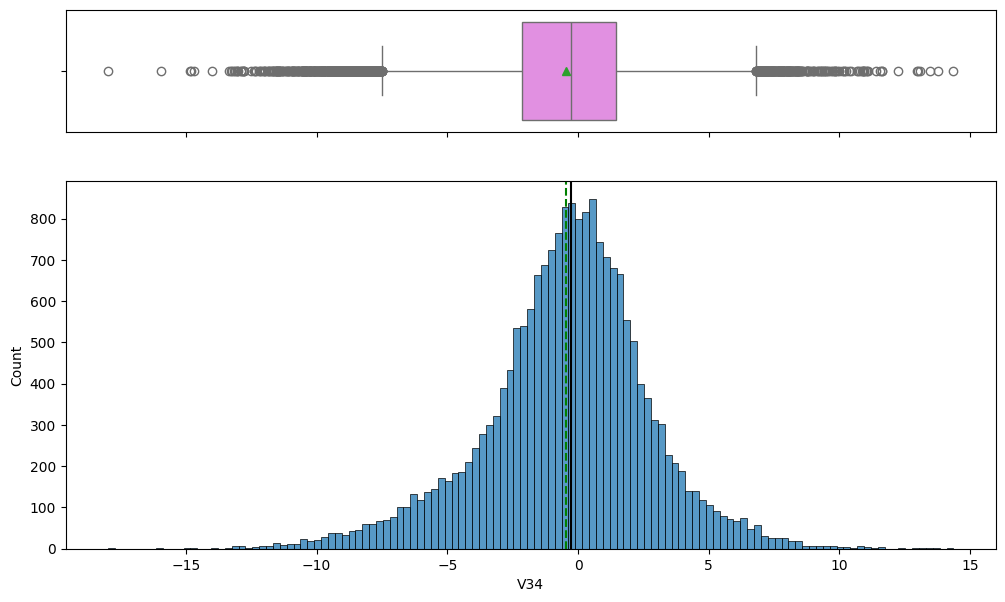

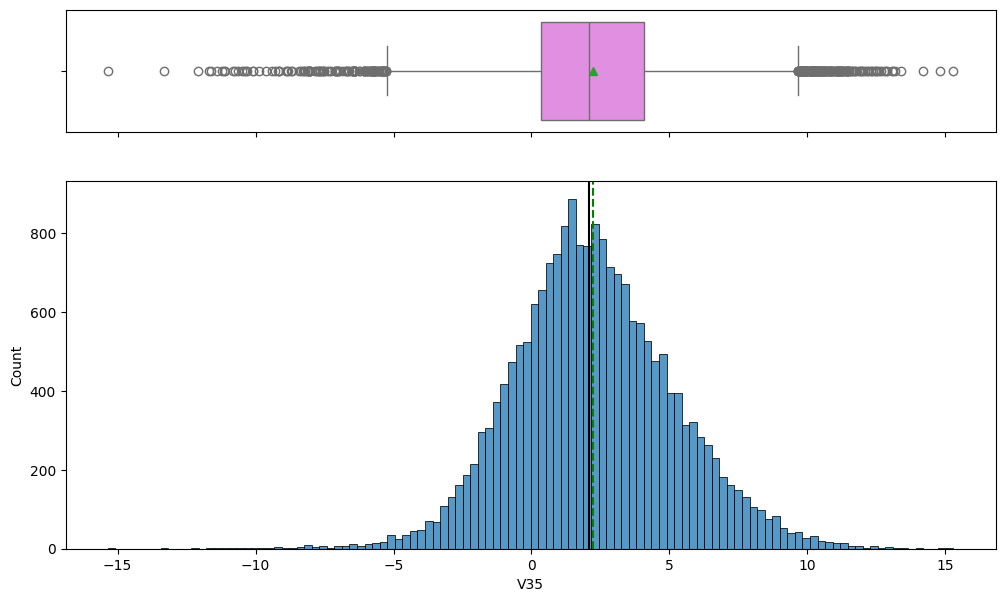

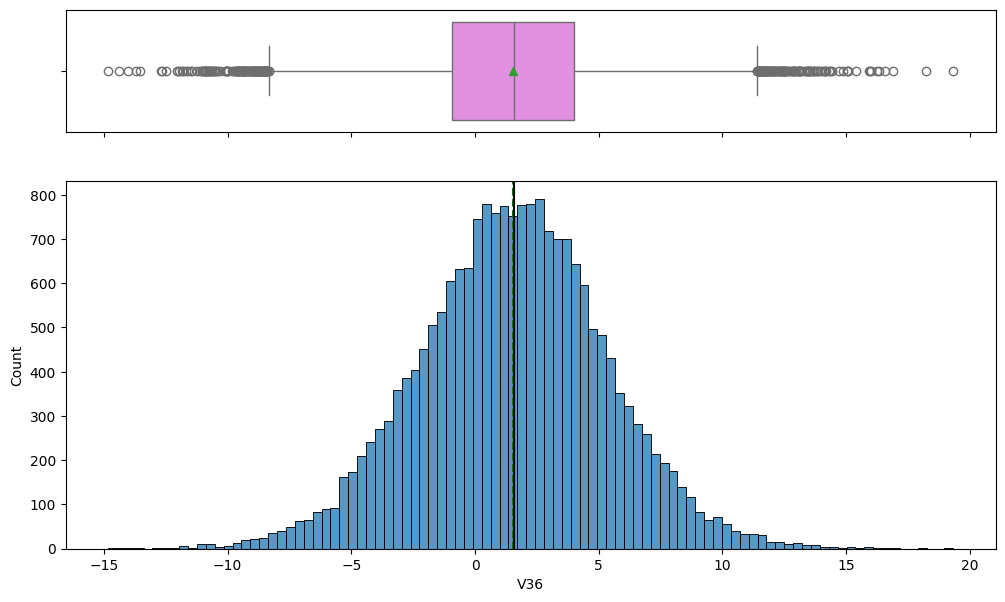

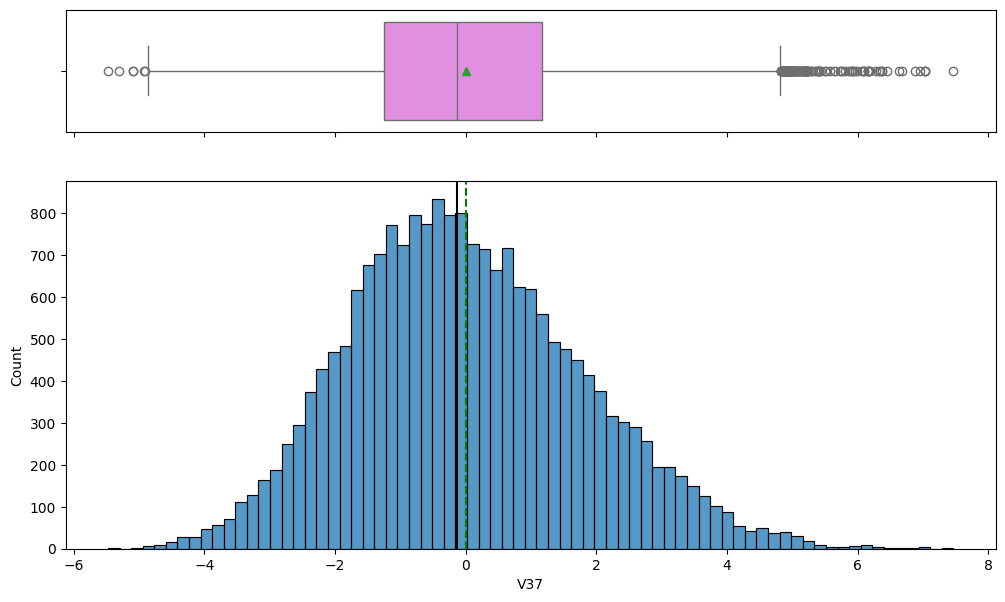

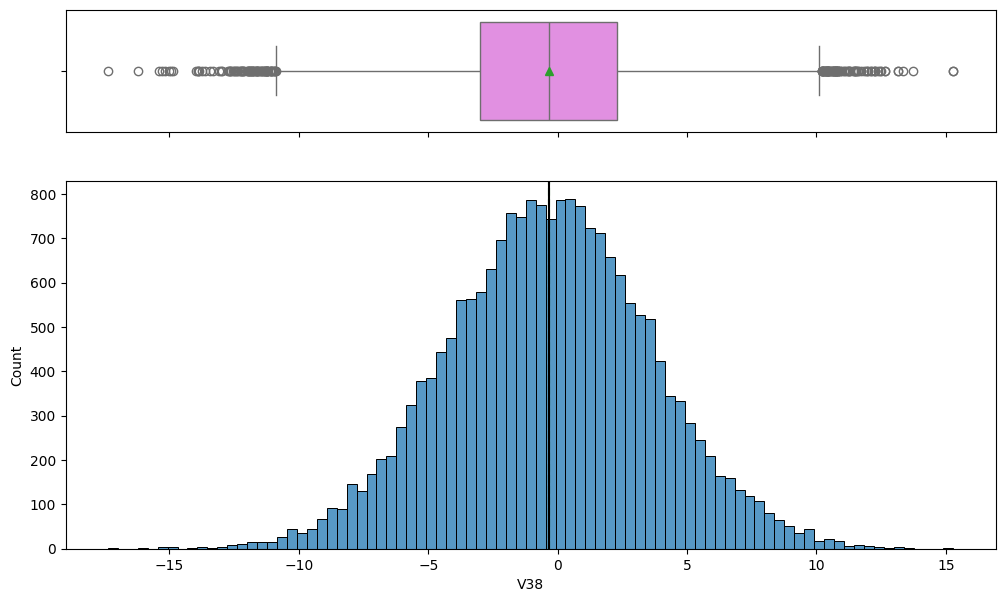

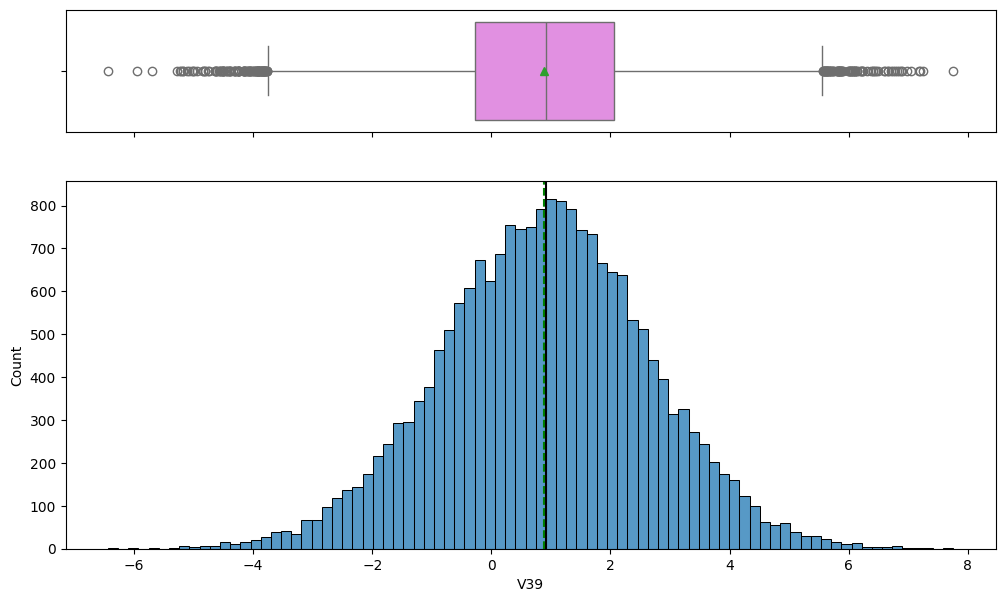

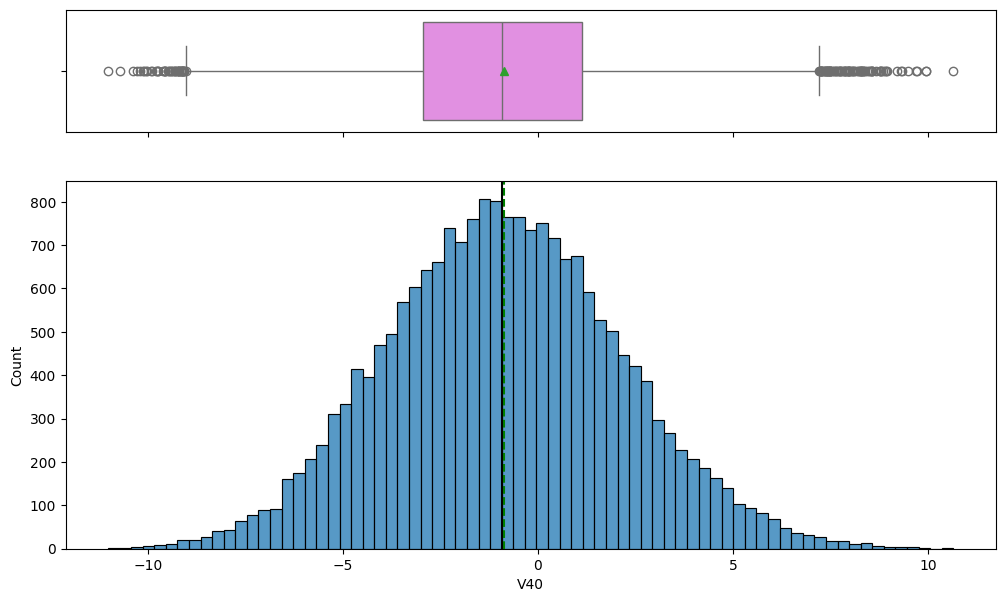

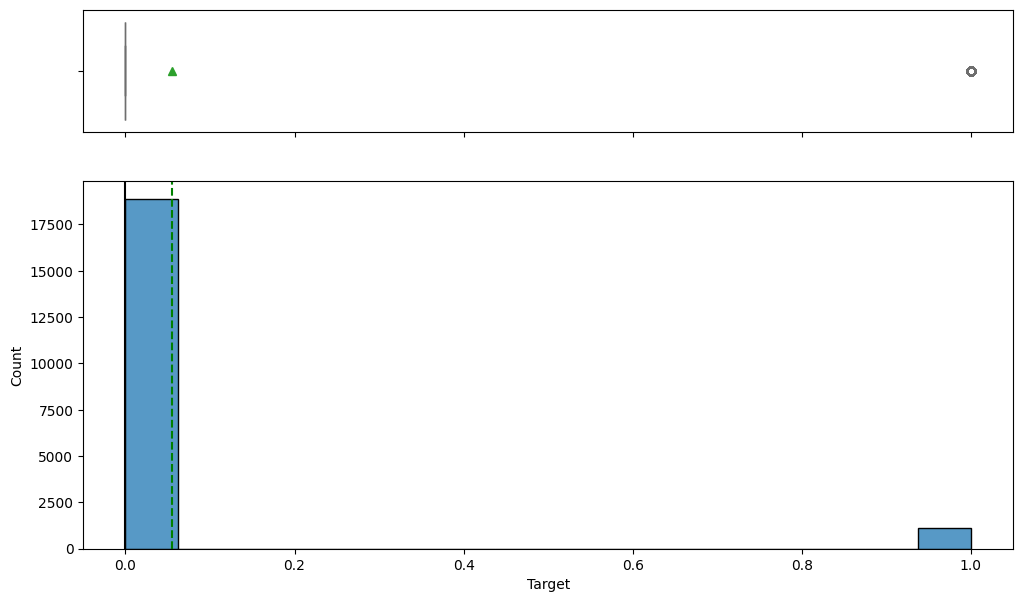

In [ ]:
for feature in df_copy.columns:
    histogram_boxplot(df, feature, figsize=(12, 7), kde=False, bins=None)

Normally distributed data.

## Distribution of Target Variable

In [ ]:
# Train data target distribution
df_copy["Target"].value_counts(1)

,proportion
Target,
0,0.9445
1,0.0555


In [ ]:
#Test data target distribuioin
df_test_copy["Target"].value_counts(1)

,proportion
Target,
0,0.9436
1,0.0564


Data is very skewed to no failures. Will have either oversample the lower class or undersample the higher class.

## Bivariate Analysis

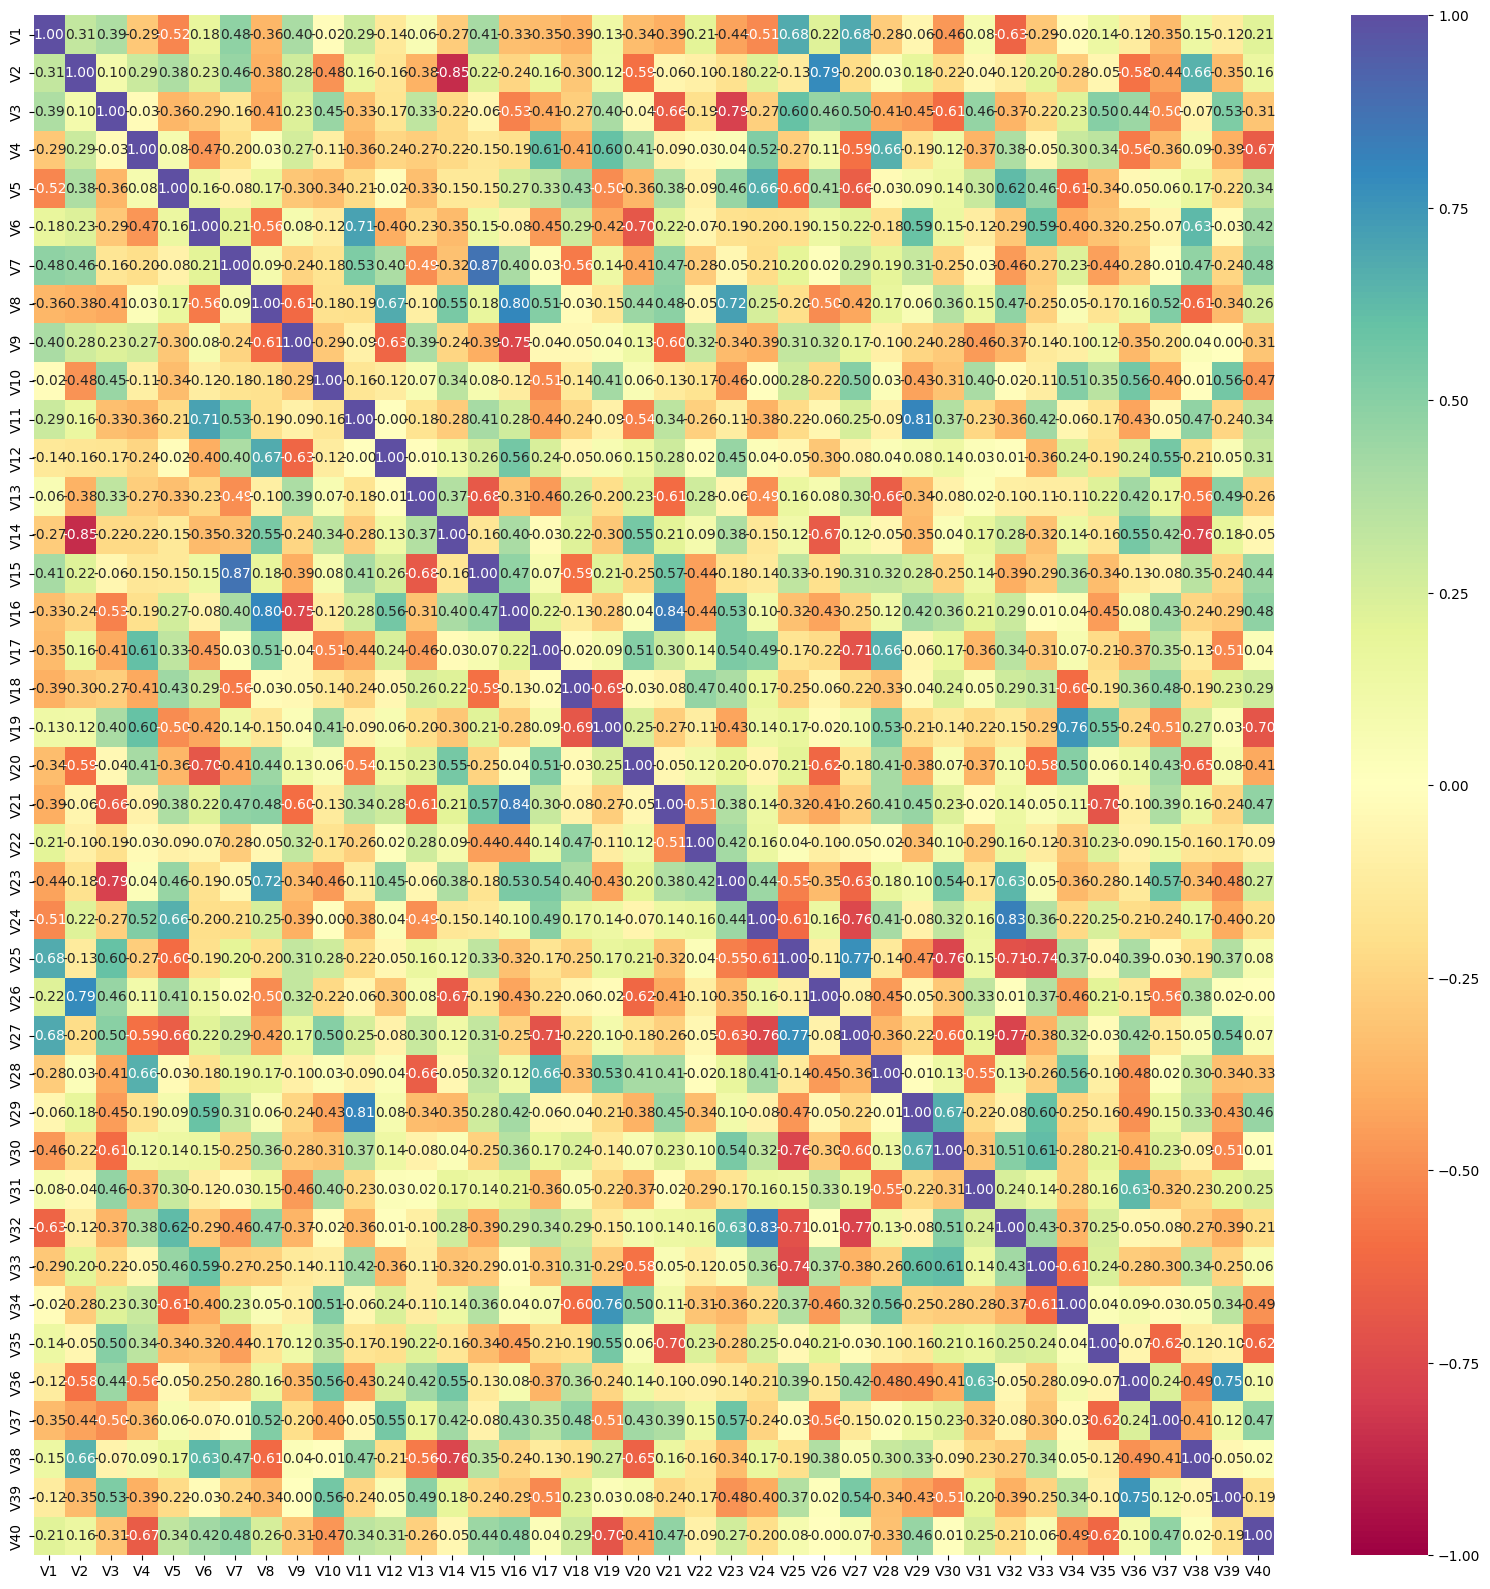

In [ ]:
#Corrleation Check
cols_list = df.select_dtypes(include=np.number).columns.tolist()
cols_list.remove("Target")

plt.figure(figsize=(20, 20))
sns.heatmap(
    df[cols_list].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral"
)
plt.show()

Very large table, but some values track quite nicely. (ie. V22 to V33)

# **Data Preprocessing**

## Data Preparation for Modeling

In [ ]:
# Dividing train data into X and y
X = df_copy.drop(columns = "Target" , axis=1)
y = df_copy["Target"] # Complete the code to select the column named 'Target'

In [ ]:
#Split the train set into smaller train and validation sets
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=1, stratify=y
)

In [ ]:
#Get the number of rows and columns in the training and validation sets
print("Training Set", X_train.shape)
print("Validation Set", X_val.shape)

Training Set (16000, 40)
Validation Set (4000, 40)


In [ ]:
# Divide the test data into X_test and y_test
X_test = df_test_copy.drop(columns = ['Target'] , axis= 1) # Complete the code to remove the target column
y_test = df_test_copy["Target"] # Complete the code to select the target column

In [ ]:
#Get the number of rows and columns in the test and validation sets
print("Test Set", X_test.shape)

Test Set (5000, 40)


## Calculate Missing Values via Imputation

In [ ]:
#Make a simple imputer to calculate missing values
imputer = SimpleImputer(strategy="median")

In [ ]:
# Fit and transform the train data
X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)

# Transform the validation data
X_val = pd.DataFrame(imputer.fit_transform(X_val), columns=X_train.columns)    # Complete the code to impute missing values in the validation set while accounting for data leakage

# Transform the test data
X_test = pd.DataFrame(imputer.fit_transform(X_test), columns=X_train.columns)    # Complete the code to impute missing values in the test set while accounting for data leakage

In [ ]:
# Check that no column has missing values in train or test sets
print(X_train.isna().sum())
print("-" * 30)
print(X_val.isna().sum())
print("-" * 30)
print(X_test.isna().sum())

V1     0
V2     0
V3     0
V4     0
V5     0
V6     0
V7     0
V8     0
V9     0
V10    0
V11    0
V12    0
V13    0
V14    0
V15    0
V16    0
V17    0
V18    0
V19    0
V20    0
V21    0
V22    0
V23    0
V24    0
V25    0
V26    0
V27    0
V28    0
V29    0
V30    0
V31    0
V32    0
V33    0
V34    0
V35    0
V36    0
V37    0
V38    0
V39    0
V40    0
dtype: int64
------------------------------
V1     0
V2     0
V3     0
V4     0
V5     0
V6     0
V7     0
V8     0
V9     0
V10    0
V11    0
V12    0
V13    0
V14    0
V15    0
V16    0
V17    0
V18    0
V19    0
V20    0
V21    0
V22    0
V23    0
V24    0
V25    0
V26    0
V27    0
V28    0
V29    0
V30    0
V31    0
V32    0
V33    0
V34    0
V35    0
V36    0
V37    0
V38    0
V39    0
V40    0
dtype: int64
------------------------------
V1     0
V2     0
V3     0
V4     0
V5     0
V6     0
V7     0
V8     0
V9     0
V10    0
V11    0
V12    0
V13    0
V14    0
V15    0
V16    0
V17    0
V18    0
V19    0
V20    0
V21    0
V22

Looks good. No missing values

In [ ]:
y_train = y_train.to_numpy()
y_val = y_val.to_numpy()
y_test = y_test.to_numpy()

# **Model Building**

## Model Evaluation Criterion

Write down the model evaluation criterion with rationale <br>
Recall is the chosen metric since we don't want false negatives indicating things are good when they are really bad (ie. part is really bad = 1).

In [ ]:
def plot(history, name):
    """
    Function to plot loss/accuracy

    history: an object which stores the metrics and losses.
    name: can be one of Loss or Accuracy
    """
    fig, ax = plt.subplots() #Creating a subplot with figure and axes.
    plt.plot(history.history[name]) #Plotting the train accuracy or train loss
    plt.plot(history.history['val_'+name]) #Plotting the validation accuracy or validation loss

    plt.title('Model ' + name.capitalize()) #Defining the title of the plot.
    plt.ylabel(name.capitalize()) #Capitalizing the first letter.
    plt.xlabel('Epoch') #Defining the label for the x-axis.
    fig.legend(['Train', 'Validation'], loc="outside right upper") #Defining the legend, loc controls the position of the legend.

In [ ]:
# defining a function to compute different metrics to check performance of a classification model built using statsmodels
def model_performance_classification(
    model, predictors, target, threshold=0.5
):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    threshold: threshold for classifying the observation as class 1
    """

    # checking which probabilities are greater than threshold
    pred = model.predict(predictors) > threshold
    # pred_temp = model.predict(predictors) > threshold
    # # rounding off the above values to get classes
    # pred = np.round(pred_temp)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred, average='macro')  # to compute Recall
    precision = precision_score(target, pred, average='macro')  # to compute Precision
    f1 = f1_score(target, pred, average='macro')  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1 Score": f1,}, index = [0]
    )

    return df_perf

## Initial Model Building (Model 0)

- Let's start with a neural network consisting of
  - just one hidden layer
  - activation function of ReLU
  - SGD as the optimizer

In [ ]:
# define the epochs and batch_size t as we'll be using the same values for all models moving ahead
epochs = 50
batch_size = 32

In [ ]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [ ]:
#Initialize the neural network
model_0 = tf.keras.Sequential([
tf.keras.layers.Dense(64,activation="relu",input_dim=X_train.shape[1]), #Hidden layer w 64 neurons, ReLU activation
tf.keras.layers.Dense(1,activation="sigmoid") # Output layer with 1 neuron for binary classification
])

In [ ]:
model_0.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,689 (10.50 KB)

 Trainable params: 2,689 (10.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
optimizer = tf.keras.optimizers.SGD()   # defining SGD as the optimizer to be used
model_0.compile(loss='binary_crossentropy', optimizer=optimizer, metrics = ['Recall']) ## Recall is the metric of choice chosen.

In [ ]:
start = time.time()
history = model_0.fit(X_train, y_train, validation_data=(X_val,y_val) , batch_size=batch_size, epochs=epochs)
end=time.time()

Epoch 1/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.3448 - loss: 0.1810 - val_Recall: 0.5631 - val_loss: 0.1025
Epoch 2/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - Recall: 0.5993 - loss: 0.0945 - val_Recall: 0.7207 - val_loss: 0.0887
Epoch 3/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - Recall: 0.6713 - loss: 0.0833 - val_Recall: 0.7432 - val_loss: 0.0807
Epoch 4/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - Recall: 0.7045 - loss: 0.0821 - val_Recall: 0.7838 - val_loss: 0.0772
Epoch 5/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - Recall: 0.7462 - loss: 0.0750 - val_Recall: 0.7928 - val_loss: 0.0744
Epoch 6/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - Recall: 0.7951 - loss: 0.0599 - val_Recall: 0.7883 - val_loss: 0.0723
Epoch 7/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - Recall: 0.7933 - loss: 0.0691 - val_Recall: 0.8018 - val_loss: 0.0715
Epoch 8/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - Recall: 0.7895 - loss: 0.0632 - val_Recall: 0.7973 - val_loss: 0.0697
Epoch 9/

In [ ]:
print("Time taken in seconds ",end-start)

Time taken in seconds  38.3556969165802


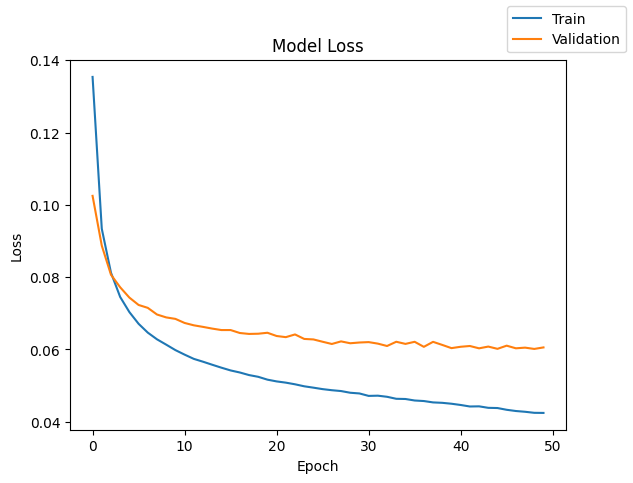

In [ ]:
plot(history,'loss')

So

So the validation loss tapers off around 10 epochs, whild the training loss continues to decrease.

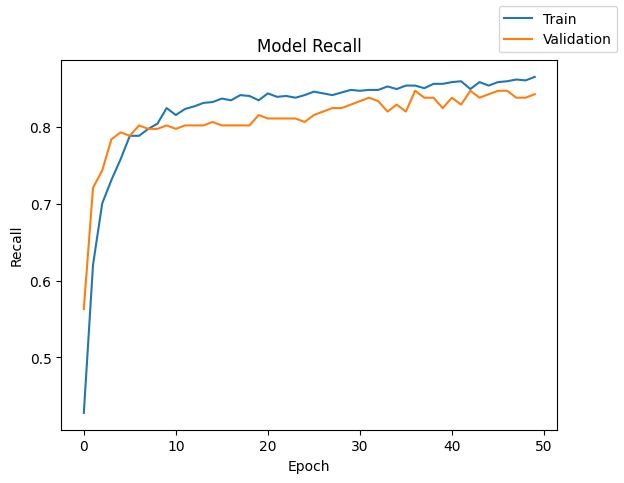

In [ ]:
plot(history,'Recall')

In [ ]:
model_0_train_perf = model_performance_classification(model_0, X_train, y_train)
model_0_train_perf

500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 679us/step


,Accuracy,Recall,Precision,F1 Score
0,0.991938,0.933725,0.988493,0.959274


In [ ]:
model_0_val_perf = model_performance_classification(model_0,X_val,y_val)
model_0_val_perf

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 763us/step


,Accuracy,Recall,Precision,F1 Score
0,0.98925,0.920112,0.974888,0.945606


Check the classification reports.

In [ ]:
y_val_pred_0 = model_0.predict(X_val)
print("Classification Report - Validation data Model_0",end="\n\n")
cr_val_model_0 = classification_report(y_val,y_val_pred_0>0.5)
print(cr_val_model_0)

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 731us/step
Classification Report - Validation data Model_0

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      3778
           1       0.96      0.84      0.90       222

    accuracy                           0.99      4000
   macro avg       0.97      0.92      0.95      4000
weighted avg       0.99      0.99      0.99      4000



# **Model Performance Improvement**

## Model 1

In [ ]:
#Add another layer to attempt to imporvoe the model's performance
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [ ]:
model_1 = tf.keras.Sequential([
tf.keras.layers.Dense( 64 ,activation="relu",input_dim=X_train.shape[1]),
tf.keras.layers.Dense( 32,activation="relu"),
tf.keras.layers.Dense(1,activation="sigmoid")
])

In [ ]:
model_1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,737 (18.50 KB)

 Trainable params: 4,737 (18.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
optimizer = tf.keras.optimizers.SGD()   # defining SGD as the optimizer to be used
model_1.compile(loss='binary_crossentropy', optimizer=optimizer, metrics = ['Recall']) ## Recall is the metric of choice chosen.

In [ ]:
start = time.time()
history = model_1.fit(X_train, y_train, validation_data=(X_val,y_val) , batch_size=batch_size, epochs=epochs)
end=time.time()

Epoch 1/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.2780 - loss: 0.1582 - val_Recall: 0.6441 - val_loss: 0.0978
Epoch 2/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - Recall: 0.6314 - loss: 0.0902 - val_Recall: 0.7162 - val_loss: 0.0847
Epoch 3/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - Recall: 0.7083 - loss: 0.0799 - val_Recall: 0.7658 - val_loss: 0.0776
Epoch 4/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - Recall: 0.7708 - loss: 0.0719 - val_Recall: 0.7838 - val_loss: 0.0735
Epoch 5/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - Recall: 0.7787 - loss: 0.0613 - val_Recall: 0.7838 - val_loss: 0.0718
Epoch 6/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - Recall: 0.8249 - loss: 0.0589 - val_Recall: 0.8108 - val_loss: 0.0696
Epoch 7/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.8179 - loss: 0.0557 - val_Recall: 0.8153 - val_loss: 0.0685
Epoch 8/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.8383 - loss: 0.0539 - val_Recall: 0.8108 - val_loss: 0.0663
Epoch 9/

In [ ]:
print("Time taken in seconds ",end-start)

Time taken in seconds  40.35101771354675


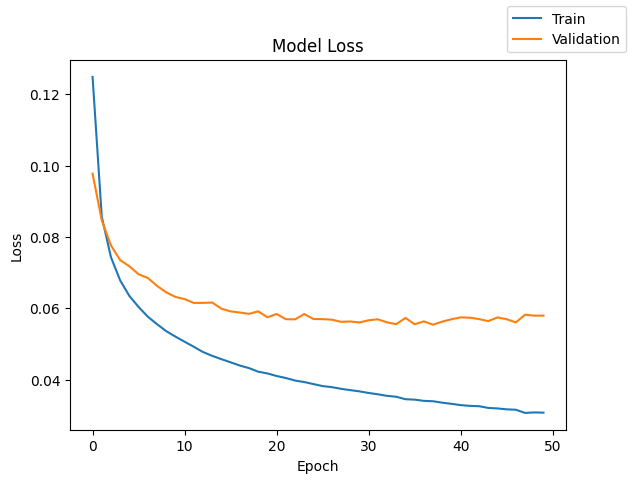

In [ ]:
plot(history,'loss')

Still bad on validation loss.

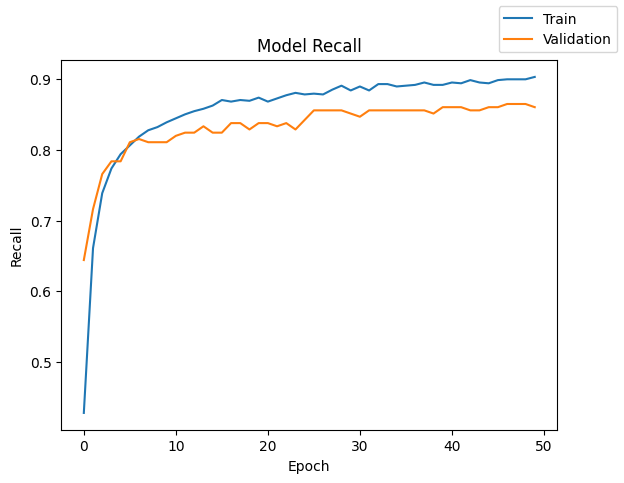

In [ ]:
plot(history,'Recall')

In [ ]:
model_1_train_perf = model_performance_classification(model_1,X_train,y_train)
model_1_train_perf

500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 696us/step


,Accuracy,Recall,Precision,F1 Score
0,0.994,0.949126,0.993307,0.970047


In [ ]:
model_1_val_perf = model_performance_classification(model_1,X_val,y_val)
model_1_val_perf

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 821us/step


,Accuracy,Recall,Precision,F1 Score
0,0.99075,0.929386,0.980696,0.953407


In [ ]:
y_train_pred_1 = model_1.predict(X_train)
y_val_pred_1 = model_1.predict(X_val)

500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 705us/step
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


In [ ]:
print("Classification Report - Train data Model_1", end="\n\n")
cr_train_model_1 = classification_report(y_train,y_train_pred_1 > 0.5)
print(cr_train_model_1)

Classification Report - Train data Model_1

              precision    recall  f1-score   support

           0       0.99      1.00      1.00     15112
           1       0.99      0.90      0.94       888

    accuracy                           0.99     16000
   macro avg       0.99      0.95      0.97     16000
weighted avg       0.99      0.99      0.99     16000



In [ ]:
print("Classification Report - Validation data Model_1", end="\n\n")
cr_val_model_1 = classification_report(y_val,y_val_pred_1 > 0.5)
print(cr_val_model_1)

Classification Report - Validation data Model_1

              precision    recall  f1-score   support

           0       0.99      1.00      1.00      3778
           1       0.97      0.86      0.91       222

    accuracy                           0.99      4000
   macro avg       0.98      0.93      0.95      4000
weighted avg       0.99      0.99      0.99      4000



Only helps a little over model0.

## Model 2

In [ ]:
tf.keras.backend.clear_session()

In [ ]:
#Initializing the neural network
from tensorflow.keras.layers import Dropout
model_2 = tf.keras.Sequential([
tf.keras.layers.Dense(128,activation="relu",input_dim=X_train.shape[1]),
tf.keras.layers.Dropout(0.5), # Dropout rates listed as 50%
tf.keras.layers.Dense(64,activation = "relu"),
tf.keras.layers.Dense(32,activation = "relu"),
tf.keras.layers.Dense(1,activation="sigmoid")
])

In [ ]:
model_2.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         5,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,617 (61.00 KB)

 Trainable params: 15,617 (61.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
optimizer = tf.keras.optimizers.SGD()   # defining SGD as the optimizer to be used
model_2.compile(loss='binary_crossentropy', optimizer=optimizer, metrics = ['Recall']) ## Recall is the metric of choice chosen

In [ ]:
start = time.time()
history = model_2.fit(X_train, y_train, validation_data=(X_val,y_val) , batch_size=batch_size, epochs=epochs)
end=time.time()

Epoch 1/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - Recall: 0.1181 - loss: 0.2191 - val_Recall: 0.5405 - val_loss: 0.1082
Epoch 2/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - Recall: 0.4269 - loss: 0.1316 - val_Recall: 0.7162 - val_loss: 0.0880
Epoch 3/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.5720 - loss: 0.1095 - val_Recall: 0.7568 - val_loss: 0.0790
Epoch 4/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - Recall: 0.5950 - loss: 0.1008 - val_Recall: 0.7658 - val_loss: 0.0733
Epoch 5/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.6438 - loss: 0.0872 - val_Recall: 0.7793 - val_loss: 0.0696
Epoch 6/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.6940 - loss: 0.0849 - val_Recall: 0.7883 - val_loss: 0.0676
Epoch 7/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.7036 - loss: 0.0838 - val_Recall: 0.7838 - val_loss: 0.0678
Epoch 8/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.6880 - loss: 0.0890 - val_Recall: 0.7883 - val_loss: 0.0654
Epoch 9/

In [ ]:
print("Time taken in seconds ",end-start)

Time taken in seconds  44.14633893966675


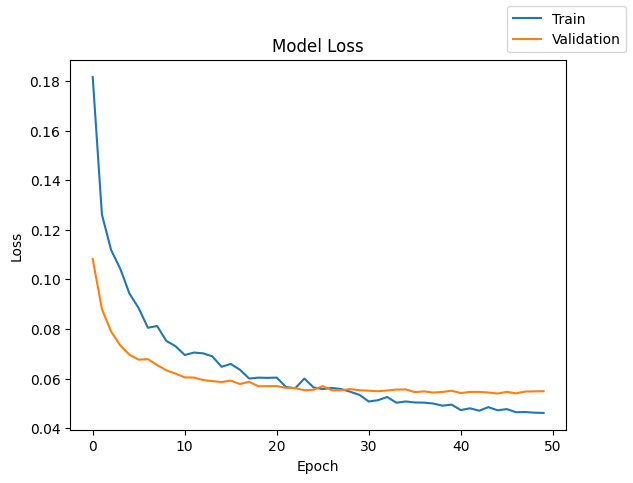

In [ ]:
plot(history,'loss')

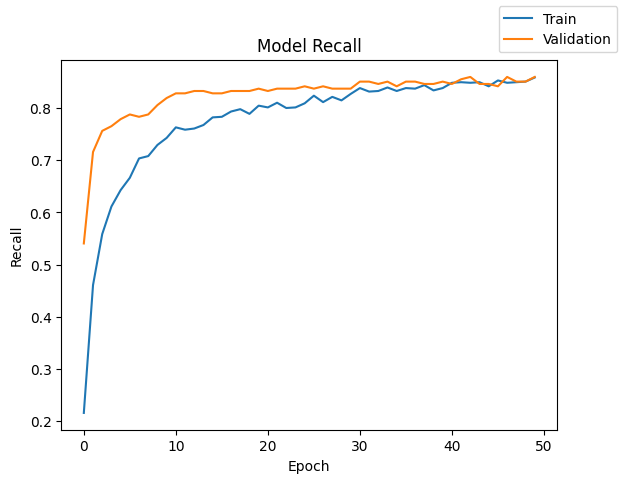

In [ ]:
plot(history,'Recall')

In [ ]:
#Check the model performance on training and validation data
model_2_train_perf = model_performance_classification(model_2,X_train,y_train)
model_2_train_perf

500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 694us/step


,Accuracy,Recall,Precision,F1 Score
0,0.993313,0.945582,0.989992,0.966597


In [ ]:
model_2_val_perf = model_performance_classification(model_2,X_val,y_val)
model_2_val_perf

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 752us/step


,Accuracy,Recall,Precision,F1 Score
0,0.99125,0.929651,0.98567,0.955726


In [ ]:
y_train_pred_2 = model_2.predict(X_train)
y_val_pred_2 = model_2.predict(X_val)

500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 741us/step
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 753us/step


In [ ]:
#Get the classification report on the training and validation data
print("Classification Report - Train data Model_2", end="\n\n")
cr_train_model_2 = classification_report(y_train,y_train_pred_2 > 0.5)
print(cr_train_model_2)

Classification Report - Train data Model_2

              precision    recall  f1-score   support

           0       0.99      1.00      1.00     15112
           1       0.99      0.89      0.94       888

    accuracy                           0.99     16000
   macro avg       0.99      0.95      0.97     16000
weighted avg       0.99      0.99      0.99     16000



Good precision, recall, and F1 scores for the train data

In [ ]:
print("Classification Report - Validation data Model_2", end="\n\n")
cr_val_model_2 = classification_report(y_val , y_val_pred_2 > 0.5)
print(cr_val_model_2)

Classification Report - Validation data Model_2

              precision    recall  f1-score   support

           0       0.99      1.00      1.00      3778
           1       0.98      0.86      0.92       222

    accuracy                           0.99      4000
   macro avg       0.99      0.93      0.96      4000
weighted avg       0.99      0.99      0.99      4000



Not so good for the validation data. Something needs to change.

## Model 3

There is a strong imbalance in class distribution with 0 (no failure) about 10x as commong as 1 (failure).

In [ ]:
# Calculate class weights for imbalanced dataset
cw = (y_train.shape[0]) / np.bincount(y_train.astype(int)) # Convert y_train to integers

# Create a dictionary mapping class indices to their respective class weights
cw_dict = {}
for i in range(cw.shape[0]):
    cw_dict[i] = cw[i]

cw_dict

{0: np.float64(1.0587612493382743), 1: np.float64(18.01801801801802)}

In [ ]:
tf.keras.backend.clear_session()

In [ ]:
model_3 = tf.keras.Sequential([
tf.keras.layers.Dense(128,activation="relu",input_dim=X_train.shape[1]), # Define the number of neurons and activation function
tf.keras.layers.Dropout(0.5), # Define the dropout rate
tf.keras.layers.Dense(64,activation="relu"), # Define the number of neurons and activation function
tf.keras.layers.Dense(32, activation = "relu"), # Define the number of neurons and activation function
tf.keras.layers.Dense(1,activation="sigmoid") # Define the number of neurons in the output layer
                              ])

In [ ]:
optimizer = tf.keras.optimizers.SGD()   # defining SGD as the optimizer to be used
model_3.compile(loss='binary_crossentropy', optimizer=optimizer, metrics = ['Recall']) ## Recall is the metric of choice chosen.

In [ ]:
start = time.time()
history = model_3.fit(X_train, y_train, validation_data=(X_val,y_val) , batch_size=batch_size, epochs=epochs, class_weight=cw_dict)
end=time.time()

Epoch 1/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.7795 - loss: 0.9389 - val_Recall: 0.9009 - val_loss: 0.2383
Epoch 2/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.8774 - loss: 0.5325 - val_Recall: 0.8829 - val_loss: 0.2412
Epoch 3/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.8714 - loss: 0.5189 - val_Recall: 0.8829 - val_loss: 0.1631
Epoch 4/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.8785 - loss: 0.5252 - val_Recall: 0.8874 - val_loss: 0.1553
Epoch 5/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.8917 - loss: 0.4289 - val_Recall: 0.8784 - val_loss: 0.1751
Epoch 6/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.8955 - loss: 0.4469 - val_Recall: 0.8829 - val_loss: 0.1365
Epoch 7/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.8983 - loss: 0.4064 - val_Recall: 0.8874 - val_loss: 0.1512
Epoch 8/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.8962 - loss: 0.4059 - val_Recall: 0.8874 - val_loss: 0.1244
Epoch 9/

In [ ]:
print("Time taken in seconds ",end-start)

Time taken in seconds  43.636629819869995


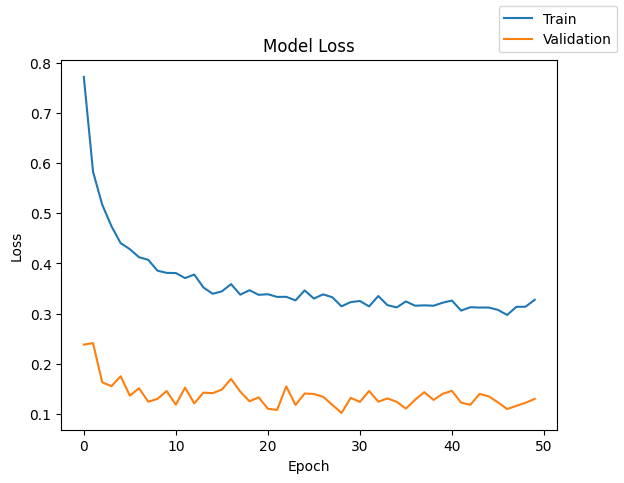

In [ ]:
plot(history,'loss')

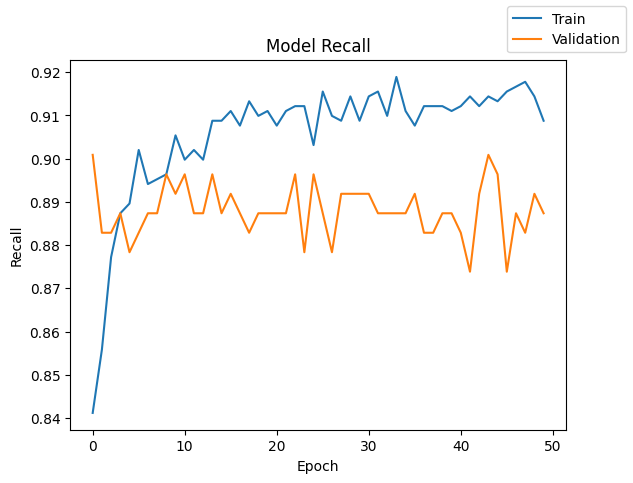

In [ ]:
plot(history,'Recall')

Check the model performace on model 3 train and validation data

In [ ]:
model_3_train_perf = model_performance_classification(model_3,X_train,y_train)
model_3_train_perf

500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 708us/step


,Accuracy,Recall,Precision,F1 Score
0,0.992437,0.958368,0.968819,0.963527


In [ ]:
model_3_val_perf = model_performance_classification(model_3,X_val,y_val)
model_3_val_perf

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 885us/step


,Accuracy,Recall,Precision,F1 Score
0,0.9915,0.942503,0.974861,0.958035


In [ ]:
y_train_pred_3 = model_3.predict(X_train)
y_val_pred_3 = model_3.predict(X_val)

500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 771us/step
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 809us/step


Check the classification report of model 3 training and validatation data

In [ ]:
print("Classification Report - Train data Model_3", end="\n\n")
cr_train_model_3 = classification_report(y_train,y_train_pred_3 > 0.5)
print(cr_train_model_3)

Classification Report - Train data Model_3

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     15112
           1       0.94      0.92      0.93       888

    accuracy                           0.99     16000
   macro avg       0.97      0.96      0.96     16000
weighted avg       0.99      0.99      0.99     16000



In [ ]:
print("Classification Report - Validation data Model_3", end="\n\n")
cr_val_model_3 = classification_report(y_val,y_val_pred_3 > 0.5)
print(cr_val_model_3)

Classification Report - Validation data Model_3

              precision    recall  f1-score   support

           0       0.99      1.00      1.00      3778
           1       0.96      0.89      0.92       222

    accuracy                           0.99      4000
   macro avg       0.97      0.94      0.96      4000
weighted avg       0.99      0.99      0.99      4000



Enhanced recall score when addressing the class imbalance.

## Model 4

Try using the Adam Optimizer

In [ ]:
tf.keras.backend.clear_session()

In [ ]:
#Neural network initialized
#Initializing the neural network
model_4 = tf.keras.Sequential([
tf.keras.layers.Dense(64,activation="relu",input_dim=X_train.shape[1]), # Define the number of neurons and activation function
tf.keras.layers.Dense(32,activation="relu"), # Define the number of neurons and activation function
tf.keras.layers.Dense(1,activation="sigmoid") # Define the number of neurons in the output layer
                              ])

In [ ]:
model_4.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,737 (18.50 KB)

 Trainable params: 4,737 (18.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
optimizer = tf.keras.optimizers.Adam()    # defining Adam as the optimizer to be used
model_4.compile(loss='binary_crossentropy', optimizer=optimizer, metrics = ['Recall']) ## Recall is the metric of choice chosen.

In [ ]:
start = time.time()
history = model_4.fit(X_train, y_train, validation_data=(X_val,y_val) , batch_size=batch_size, epochs=epochs)
end=time.time()

Epoch 1/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - Recall: 0.4078 - loss: 0.1649 - val_Recall: 0.8153 - val_loss: 0.0664
Epoch 2/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - Recall: 0.8172 - loss: 0.0598 - val_Recall: 0.8468 - val_loss: 0.0597
Epoch 3/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - Recall: 0.8444 - loss: 0.0514 - val_Recall: 0.8423 - val_loss: 0.0590
Epoch 4/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - Recall: 0.8787 - loss: 0.0437 - val_Recall: 0.8559 - val_loss: 0.0568
Epoch 5/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - Recall: 0.8614 - loss: 0.0385 - val_Recall: 0.8604 - val_loss: 0.0594
Epoch 6/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.8734 - loss: 0.0432 - val_Recall: 0.8468 - val_loss: 0.0593
Epoch 7/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.8891 - loss: 0.0421 - val_Recall: 0.8468 - val_loss: 0.0591
Epoch 8/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - Recall: 0.8705 - loss: 0.0377 - val_Recall: 0.8514 - val_loss: 0.0591
Epoch 9/

In [ ]:
print("Time taken in seconds ",end-start)

Time taken in seconds  41.80377697944641


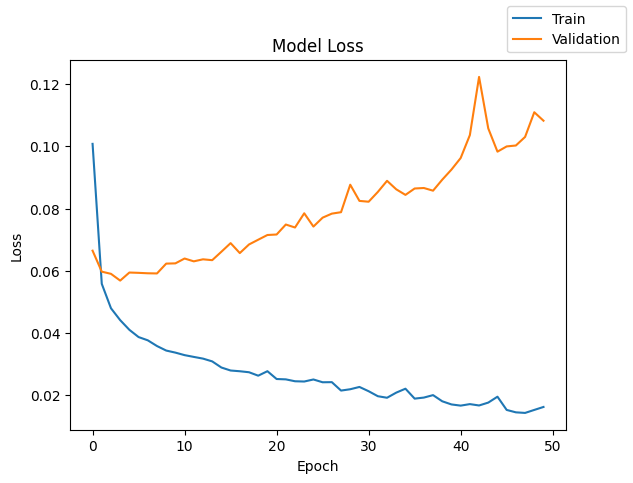

In [ ]:
plot(history,'loss')

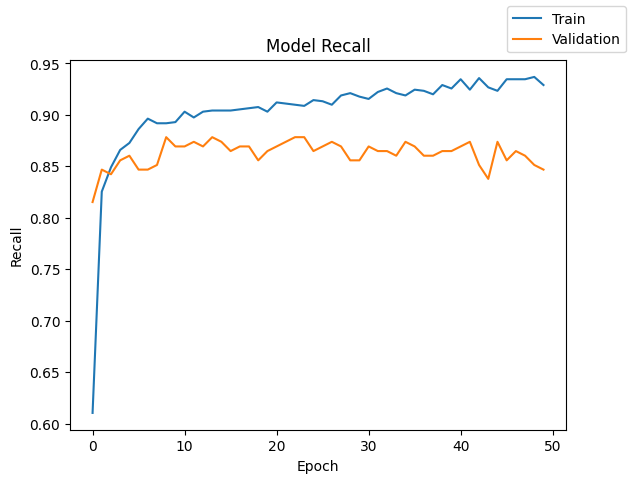

In [ ]:
plot(history,'Recall')

In [ ]:
#Check the model performance of model 4 on training and validation data
model_4_train_perf = model_performance_classification(model_4,X_train,y_train)
model_4_train_perf

500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 992us/step


,Accuracy,Recall,Precision,F1 Score
0,0.996188,0.966713,0.996852,0.98125


In [ ]:
model_4_val_perf = model_performance_classification(model_4,X_val,y_val)
model_4_val_perf

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 866us/step


,Accuracy,Recall,Precision,F1 Score
0,0.98925,0.922232,0.972687,0.945851


In [ ]:
y_train_pred_4 = model_4.predict(X_train)
y_val_pred_4 = model_4.predict(X_val)

500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 738us/step
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 756us/step


In [ ]:
#Get the classification reports on the training and validation data
print("Classification Report - Train data Model_4", end="\n\n")
cr_train_model_4 = classification_report(y_train,y_train_pred_4 > 0.5)
print(cr_train_model_4)

Classification Report - Train data Model_4

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     15112
           1       1.00      0.93      0.96       888

    accuracy                           1.00     16000
   macro avg       1.00      0.97      0.98     16000
weighted avg       1.00      1.00      1.00     16000



In [ ]:
print("Classification Report - Validation data Model_4", end="\n\n")
cr_val_model_4 = classification_report(y_val,y_val_pred_4 > 0.5)
print(cr_val_model_4)

Classification Report - Validation data Model_4

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      3778
           1       0.95      0.85      0.90       222

    accuracy                           0.99      4000
   macro avg       0.97      0.92      0.95      4000
weighted avg       0.99      0.99      0.99      4000



Adam Optimizer is superior to SGD, keeping everything else the same.

## Model 5

Add more layers while keeping the Adam optimizer. <br>
Switch to analogous sequential then add syntax from tf.keras.Sequential and ([ since this was mentioned in the low code notebook. I've demonstrated knowledge of both approaches.

In [ ]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [ ]:
#Initializing the neural network
from tensorflow.keras.layers import Dropout
model_5 = Sequential()
model_5.add(Dense(128,activation="relu",input_dim=X_train.shape[1])) # Define the number of neurons and activation function
model_5.add(Dropout(0.5)) #Define the dropout rate
model_5.add(Dense(64,activation="relu"))
model_5.add(Dense(32, activation = "relu"))
model_5.add(Dense(1,activation="sigmoid"))

In [ ]:
model_5.summary()
#

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         5,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,617 (61.00 KB)

 Trainable params: 15,617 (61.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
optimizer = tf.keras.optimizers.Adam()    # defining Adam as the optimizer to be used
model_5.compile(loss='binary_crossentropy', optimizer=optimizer, metrics = ['Recall']) #Recall is the metric chosen

In [ ]:
start = time.time()
history = model_5.fit(X_train, y_train, validation_data=(X_val,y_val) , batch_size=batch_size, epochs=epochs)
end=time.time()

Epoch 1/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - Recall: 0.3093 - loss: 0.1839 - val_Recall: 0.7748 - val_loss: 0.0705
Epoch 2/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.7174 - loss: 0.0759 - val_Recall: 0.8288 - val_loss: 0.0589
Epoch 3/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.7806 - loss: 0.0650 - val_Recall: 0.8423 - val_loss: 0.0589
Epoch 4/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.8276 - loss: 0.0576 - val_Recall: 0.8559 - val_loss: 0.0575
Epoch 5/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.8309 - loss: 0.0562 - val_Recall: 0.8559 - val_loss: 0.0553
Epoch 6/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.8394 - loss: 0.0528 - val_Recall: 0.8514 - val_loss: 0.0576
Epoch 7/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.8503 - loss: 0.0477 - val_Recall: 0.8649 - val_loss: 0.0581
Epoch 8/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.8686 - loss: 0.0471 - val_Recall: 0.8604 - val_loss: 0.0578
Epoch 9/

In [ ]:
print("Time taken in seconds ",end-start)

Time taken in seconds  50.59476828575134


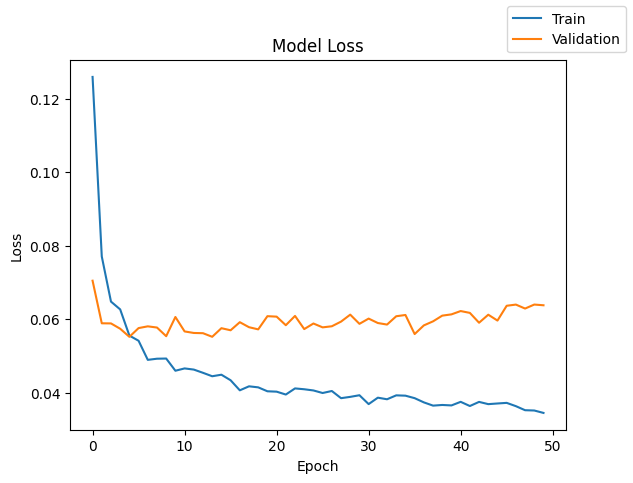

In [ ]:
plot(history,'loss')

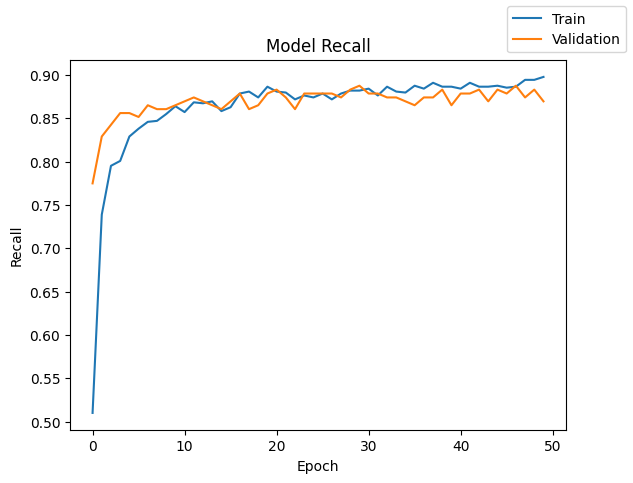

In [ ]:
plot(history, 'Recall')

Check on Model 5's performance on training and validation data.

In [ ]:
model_5_train_perf = model_performance_classification(model_5,X_train,y_train)
model_5_train_perf

500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 760us/step


,Accuracy,Recall,Precision,F1 Score
0,0.994563,0.952073,0.995961,0.972871


In [ ]:
model_5_val_perf = model_performance_classification(model_5,X_val,y_val)
model_5_val_perf

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 871us/step


,Accuracy,Recall,Precision,F1 Score
0,0.99225,0.93442,0.991061,0.960786


In [ ]:
y_train_pred_5 = model_5.predict(X_train)
y_val_pred_5 = model_5.predict(X_val)

500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 779us/step
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 833us/step


Get the classification reports for model 5.

In [ ]:
print("Classification Report - Train data Model_5", end="\n\n")
cr_train_model_5 = classification_report(y_train,y_train_pred_5 > 0.5)
print(cr_train_model_5)

Classification Report - Train data Model_5

              precision    recall  f1-score   support

           0       0.99      1.00      1.00     15112
           1       1.00      0.90      0.95       888

    accuracy                           0.99     16000
   macro avg       1.00      0.95      0.97     16000
weighted avg       0.99      0.99      0.99     16000



In [ ]:
print("Classification Report - Validation data Model_5", end="\n\n")
cr_val_model_5 = classification_report(y_val,y_val_pred_5 > 0.5)
print(cr_val_model_5)

Classification Report - Validation data Model_5

              precision    recall  f1-score   support

           0       0.99      1.00      1.00      3778
           1       0.99      0.87      0.93       222

    accuracy                           0.99      4000
   macro avg       0.99      0.93      0.96      4000
weighted avg       0.99      0.99      0.99      4000



Adding more layers with the Adam optimizer helps.

## Model 6

Give higher importance to the minority class and see how model performance

---

changes. Keep Adam Optimizer.

In [ ]:
tf.keras.backend.clear_session()

In [ ]:
model_6 = Sequential()
model_6.add(Dense(128,activation="relu",input_dim=X_train.shape[1])) # Define the number of neurons and activation function
model_6.add(Dropout(0.5)) # Define the dropout rate
model_6.add(Dense(64,activation="relu")) # Define the number of neurons and activation function
model_6.add(Dense(32, activation = "relu")) # Define the number of neurons and activation function
model_6.add(Dense(1,activation="sigmoid")) # Define the number of neurons in the output layer

In [ ]:
optimizer = tf.keras.optimizers.Adam()    # defining Adam as the optimizer to be used
model_6.compile(loss='binary_crossentropy', optimizer=optimizer, metrics = ['Recall']) # Define Recall as the metric chosen.

In [ ]:
start = time.time()
history = model_6.fit(X_train, y_train, validation_data=(X_val,y_val) , batch_size=batch_size, epochs=epochs,class_weight=cw_dict) # Complete the code such that the model is biased towards the minority class
end=time.time()

Epoch 1/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - Recall: 0.7554 - loss: 0.9106 - val_Recall: 0.8604 - val_loss: 0.1967
Epoch 2/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.8597 - loss: 0.5864 - val_Recall: 0.8694 - val_loss: 0.1815
Epoch 3/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.8711 - loss: 0.4838 - val_Recall: 0.8739 - val_loss: 0.1552
Epoch 4/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.8903 - loss: 0.4527 - val_Recall: 0.8694 - val_loss: 0.1620
Epoch 5/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.8990 - loss: 0.4196 - val_Recall: 0.8874 - val_loss: 0.1544
Epoch 6/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.9129 - loss: 0.3735 - val_Recall: 0.8829 - val_loss: 0.1978
Epoch 7/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.9124 - loss: 0.3515 - val_Recall: 0.8829 - val_loss: 0.1243
Epoch 8/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.8922 - loss: 0.4488 - val_Recall: 0.8784 - val_loss: 0.1331
Epoch 9/

In [ ]:
print("Time taken in seconds ",end-start)

Time taken in seconds  51.106308460235596


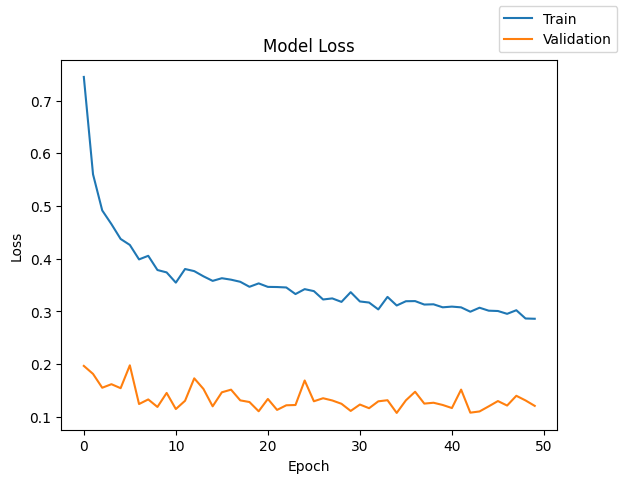

In [ ]:
plot(history,'loss')

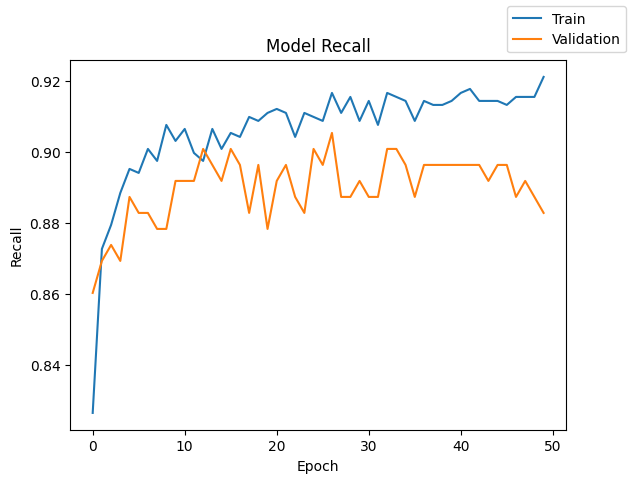

In [ ]:
plot(history, 'Recall')

Check the model 6 performance on training and test data

In [ ]:
model_6_train_perf = model_performance_classification(model_6,X_train,y_train)
model_6_train_perf

500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 842us/step


,Accuracy,Recall,Precision,F1 Score
0,0.993,0.959726,0.972779,0.966149


In [ ]:
model_6_val_perf = model_performance_classification(model_6,X_val,y_val)
model_6_val_perf

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 825us/step


,Accuracy,Recall,Precision,F1 Score
0,0.992,0.940647,0.981726,0.960152


In [ ]:
y_train_pred_6 = model_6.predict(X_train)
y_val_pred_6 = model_6.predict(X_val)

500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 781us/step
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 950us/step


Check the classification report of model 6.

In [ ]:
print("Classification Report - Train data Model_6", end="\n\n")
cr_train_model_6 = classification_report(y_train,y_train_pred_6 > 0.5)
print(cr_train_model_6)

Classification Report - Train data Model_6

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     15112
           1       0.95      0.92      0.94       888

    accuracy                           0.99     16000
   macro avg       0.97      0.96      0.97     16000
weighted avg       0.99      0.99      0.99     16000



In [ ]:
print("Classification Report - Validation data Model_6", end="\n\n")
cr_val_model_6 = classification_report(y_val,y_val_pred_6 > 0.5)
print(cr_val_model_6)

Classification Report - Validation data Model_6

              precision    recall  f1-score   support

           0       0.99      1.00      1.00      3778
           1       0.97      0.88      0.92       222

    accuracy                           0.99      4000
   macro avg       0.98      0.94      0.96      4000
weighted avg       0.99      0.99      0.99      4000



## Model 7

Keep adding more layers to arrive at even a better model than model 3. Swtich back to Adam Optimizer and add more neurons.

In [ ]:
tf.keras.backend.clear_session()

In [ ]:
#Add layers here
model_7 = tf.keras.Sequential([
tf.keras.layers.Dense(256,activation="relu",input_dim=X_train.shape[1]),
tf.keras.layers.Dropout(0.5),
tf.keras.layers.Dense(128,activation="relu"),
tf.keras.layers.Dense(64,activation="relu"),
tf.keras.layers.Dense(32, activation = "relu"),
tf.keras.layers.Dense(16, activation = "relu"),
tf.keras.layers.Dense(8, activation="relu"),
tf.keras.layers.Dense(4, activation="relu"),
tf.keras.layers.Dense(2, activation="relu"),
tf.keras.layers.Dense(1,activation="sigmoid") # Complete the code to define the number of neurons in the output layer
                              ])

In [ ]:
optimizer = tf.keras.optimizers.Adam()   # defining Adam as the optimizer to be used
model_7.compile(loss='binary_crossentropy', optimizer=optimizer, metrics = ['Recall']) ## Recall is the metric chosen.

In [ ]:
start = time.time()
history = model_7.fit(X_train, y_train, validation_data=(X_val,y_val) , batch_size=batch_size, epochs=epochs, class_weight=cw_dict)
end=time.time()

Epoch 1/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - Recall: 0.8545 - loss: 1.0447 - val_Recall: 0.8333 - val_loss: 0.5133
Epoch 2/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - Recall: 0.8723 - loss: 0.6641 - val_Recall: 0.8604 - val_loss: 0.4000
Epoch 3/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.8863 - loss: 0.5509 - val_Recall: 0.8784 - val_loss: 0.3212
Epoch 4/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.8967 - loss: 0.4727 - val_Recall: 0.8784 - val_loss: 0.2586
Epoch 5/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.8641 - loss: 0.4878 - val_Recall: 0.8829 - val_loss: 0.2315
Epoch 6/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.9050 - loss: 0.4116 - val_Recall: 0.8919 - val_loss: 0.2013
Epoch 7/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Recall: 0.9037 - loss: 0.3880 - val_Recall: 0.8829 - val_loss: 0.1818
Epoch 8/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - Recall: 0.8921 - loss: 0.3936 - val_Recall: 0.8874 - val_loss: 0.1772
Epoch 9/

In [ ]:
print("Time taken in seconds ",end-start)

Time taken in seconds  73.38645148277283


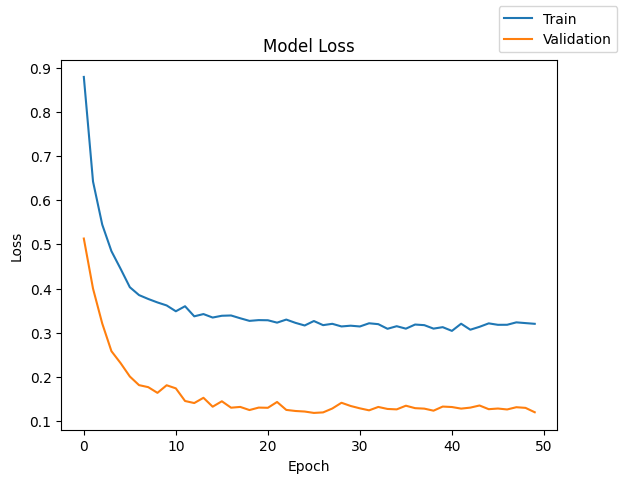

In [ ]:
plot(history, 'loss')

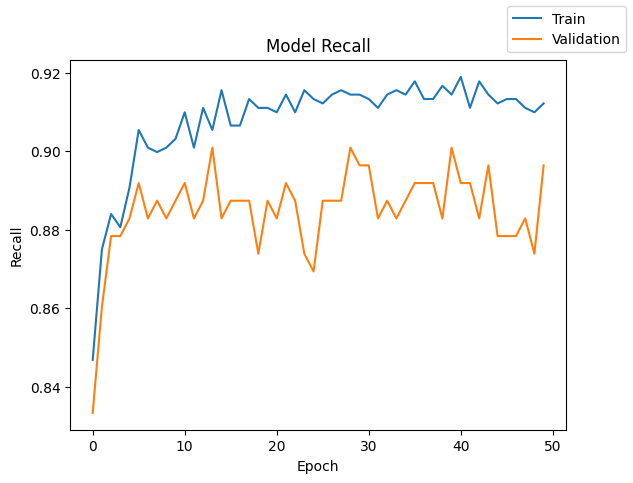

In [ ]:
plot(history, 'Recall')

Check the model7 performance on train and validation data

In [ ]:
model_7_train_perf = model_performance_classification(model_7,X_train,y_train)
model_7_train_perf

500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.992563,0.958964,0.969429,0.96413


In [ ]:
model_7_val_perf = model_performance_classification(model_7,X_val,y_val)
model_7_val_perf

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


,Accuracy,Recall,Precision,F1 Score
0,0.99025,0.946081,0.959752,0.952799


In [ ]:
y_train_pred_7 = model_7.predict(X_train)
y_val_pred_7 = model_7.predict(X_val)

500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step  
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


Check the classification report of model 7.

In [ ]:
print("Classification Report - Train data Model_7", end="\n\n")
cr_train_model_7 = classification_report(y_train,y_train_pred_7 > 0.5)
print(cr_train_model_7)

Classification Report - Train data Model_7

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     15112
           1       0.94      0.92      0.93       888

    accuracy                           0.99     16000
   macro avg       0.97      0.96      0.96     16000
weighted avg       0.99      0.99      0.99     16000



In [ ]:
print("Classification Report - Validation data Model_7", end="\n\n")
cr_val_model_7 = classification_report(y_val,y_val_pred_7 > 0.5)
print(cr_val_model_7)

Classification Report - Validation data Model_7

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      3778
           1       0.93      0.90      0.91       222

    accuracy                           0.99      4000
   macro avg       0.96      0.95      0.95      4000
weighted avg       0.99      0.99      0.99      4000



## Model 8

This model essentially replicates model 6 w Adam optimizer, but with more layers to try and achieve a higher recall score. Still addressing the class imbalance and a dropout layer.

In [ ]:
tf.keras.backend.clear_session()

In [ ]:
#Add 512 neurons at the top here to determine effed
model_8 = Sequential()
model_8.add(Dense(512,activation="relu",input_dim=X_train.shape[1]))
model_8.add(Dropout(0.5))
model_8.add(Dense(128,activation="relu",input_dim=X_train.shape[1]))
model_8.add(Dropout(0.5))
model_8.add(Dense(64,activation="relu"))
model_8.add(Dense(32, activation = "relu"))
model_8.add(Dense(1,activation="sigmoid"))

In [ ]:
optimizer = tf.keras.optimizers.Adam()    # defining Adam as the optimizer to be used
model_8.compile(loss='binary_crossentropy', optimizer=optimizer, metrics = ['Recall']) # Recall is the metric chosen.

In [ ]:
start = time.time()
history = model_8.fit(X_train, y_train, validation_data=(X_val,y_val) , batch_size=batch_size, epochs=epochs,class_weight=cw_dict) # Complete the code such that the model is biased towards the minority class
end=time.time()

Epoch 1/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - Recall: 0.7041 - loss: 1.0459 - val_Recall: 0.8378 - val_loss: 0.0973
Epoch 2/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - Recall: 0.8771 - loss: 0.6144 - val_Recall: 0.8739 - val_loss: 0.1589
Epoch 3/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - Recall: 0.8973 - loss: 0.4841 - val_Recall: 0.8919 - val_loss: 0.2082
Epoch 4/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - Recall: 0.8874 - loss: 0.4440 - val_Recall: 0.8784 - val_loss: 0.1830
Epoch 5/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - Recall: 0.8871 - loss: 0.4453 - val_Recall: 0.8784 - val_loss: 0.1529
Epoch 6/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - Recall: 0.8837 - loss: 0.4592 - val_Recall: 0.8784 - val_loss: 0.1819
Epoch 7/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - Recall: 0.8979 - loss: 0.4276 - val_Recall: 0.8874 - val_loss: 0.1966
Epoch 8/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - Recall: 0.9003 - loss: 0.3852 - val_Recall: 0.8919 - val_loss: 0.1955
Epoch 9/

In [ ]:
print("Time taken in seconds ",end-start)

Time taken in seconds  87.28269386291504


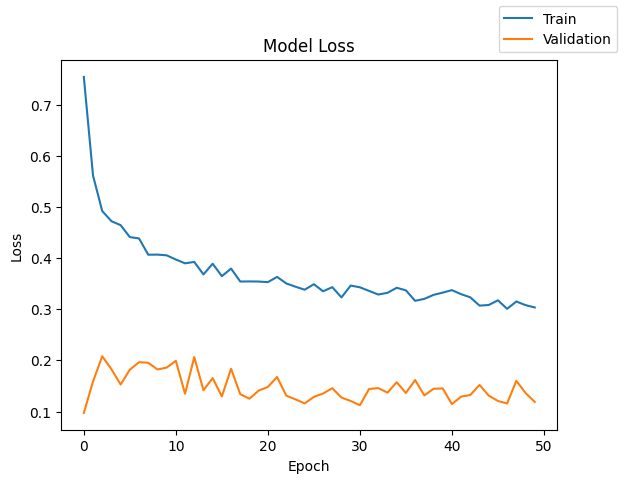

In [ ]:
plot(history,'loss')

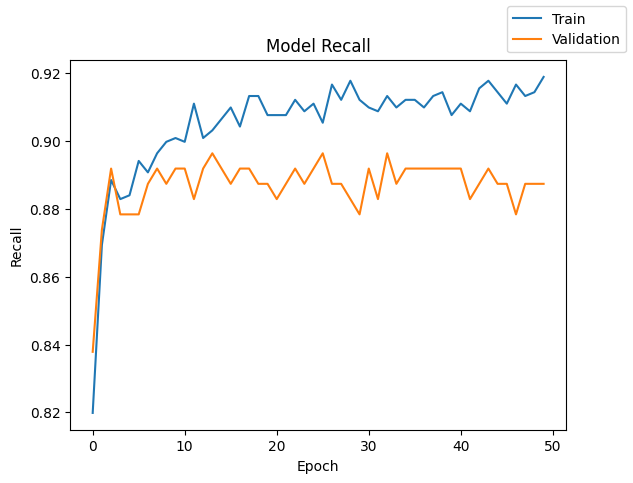

In [ ]:
plot(history,'Recall')

Check Model 8's performance on training and validation data

In [ ]:
model_8_train_perf = model_performance_classification(model_8,X_train,y_train)
model_8_train_perf

500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 917us/step


,Accuracy,Recall,Precision,F1 Score
0,0.993812,0.959626,0.980571,0.969834


In [ ]:
model_8_val_perf = model_performance_classification(model_8,X_val,y_val)
model_8_val_perf

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 900us/step


,Accuracy,Recall,Precision,F1 Score
0,0.992,0.942767,0.97955,0.960329


In [ ]:
y_train_pred_8 = model_8.predict(X_train)
y_val_pred_8 = model_8.predict(X_val)

500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 913us/step
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


Check the Classifiction Report of Model 8

In [ ]:
print("Classification Report - Train data Model_8", end="\n\n")
cr_train_model_8 = classification_report(y_train,y_train_pred_8 > 0.5)
print(cr_train_model_8)

Classification Report - Train data Model_8

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     15112
           1       0.97      0.92      0.94       888

    accuracy                           0.99     16000
   macro avg       0.98      0.96      0.97     16000
weighted avg       0.99      0.99      0.99     16000



In [ ]:
print("Classification Report - Validation data Model_8", end="\n\n")
cr_val_model_8 = classification_report(y_val,y_val_pred_8 > 0.5)
print(cr_val_model_8)

Classification Report - Validation data Model_8

              precision    recall  f1-score   support

           0       0.99      1.00      1.00      3778
           1       0.97      0.89      0.92       222

    accuracy                           0.99      4000
   macro avg       0.98      0.94      0.96      4000
weighted avg       0.99      0.99      0.99      4000



# **Model Performance Comparison and Final Model Selection**

Now, in order to select the final model, we will compare the performances of all the models for the training and validation sets.

In [ ]:
#Training peformance comparisions
models_train_comp_df = pd.concat(
    [
        model_0_train_perf.T,
        model_1_train_perf.T,
        model_2_train_perf.T,
        model_3_train_perf.T,
        model_4_train_perf.T,
        model_5_train_perf.T,
        model_6_train_perf.T,
        model_7_train_perf.T,
        model_8_train_perf.T

    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Model 0",
    "Model 1",
    "Model 2",
    "Model 3",
    "Model 4",
    "Model 5",
    "Model 6",
    "Model 7",
    "Model 8"
]
print("Training set performance comparison:")
models_train_comp_df

Training set performance comparison:


,Model 0,Model 1,Model 2,Model 3,Model 4,Model 5,Model 6,Model 7,Model 8
Accuracy,0.991938,0.994000,0.993313,0.992437,0.996188,0.994563,0.993000,0.992563,0.993812
Recall,0.933725,0.949126,0.945582,0.958368,0.966713,0.952073,0.959726,0.958964,0.959626
Precision,0.988493,0.993307,0.989992,0.968819,0.996852,0.995961,0.972779,0.969429,0.980571
F1 Score,0.959274,0.970047,0.966597,0.963527,0.981250,0.972871,0.966149,0.964130,0.969834


In [ ]:
#Validation performance comparisons.
models_val_comp_df = pd.concat(
    [
        model_0_val_perf.T,
        model_1_val_perf.T,
        model_2_val_perf.T,
        model_3_val_perf.T,
        model_4_val_perf.T,
        model_5_val_perf.T,
        model_6_val_perf.T,
        model_7_val_perf.T,
        model_8_val_perf.T

    ],
    axis=1,
)
models_val_comp_df.columns = [
    "Model 0",
    "Model 1",
    "Model 2",
    "Model 3",
    "Model 4",
    "Model 5",
    "Model 6",
    "Model 7",
    "model 8"
]
print("Validation set performance comparison:")
models_val_comp_df

Validation set performance comparison:


,Model 0,Model 1,Model 2,Model 3,Model 4,Model 5,Model 6,Model 7,model 8
Accuracy,0.989250,0.990750,0.991250,0.991500,0.989250,0.992250,0.992000,0.990250,0.992000
Recall,0.920112,0.929386,0.929651,0.942503,0.922232,0.934420,0.940647,0.946081,0.942767
Precision,0.974888,0.980696,0.985670,0.974861,0.972687,0.991061,0.981726,0.959752,0.979550
F1 Score,0.945606,0.953407,0.955726,0.958035,0.945851,0.960786,0.960152,0.952799,0.960329


In [ ]:
#Find the max recall score
max_recall_val = models_val_comp_df.loc["Recall"].max()
max_recall_val

0.9460806756995217

Model 8 has the best validation Recall score of 00.946213.

Now, let's check the performance of the final model on the test set using the best model (model_3 for maximum recall score)

Check the performance of the best model from the test set.

In [ ]:
# best_model = model_0 ## this line in case the best model is model_0
# best_model = model_1 ## this line in case the best model is model_1
# best_model = model_2 ## this line in case the best model is model_2
#best_model = model_3 ## this line in case the best model is model_3
# best_model = model_4 ## this line in case the best model is model_4
# best_model = model_5 ## this line in case the best model is model_5
# best_model = model_6 ## this line in case best model is model_6
# best_model = model_7 ## this line in case the best model is model_7
best_model = model_8

In [ ]:
# Test set performance for the best model
best_model_test_perf = model_performance_classification(best_model,X_test,y_test)
best_model_test_perf

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


,Accuracy,Recall,Precision,F1 Score
0,0.9896,0.93114,0.968861,0.949103


Model8 even outperforms the earlier models (model6, model7, and model8) on Recall.

In [ ]:
y_test_pred_best = best_model.predict(X_test)

cr_test_best_model = classification_report(y_test, y_test_pred_best>0.5) # Check the classification report of best model on test data.
print(cr_test_best_model)

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 954us/step
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      4718
           1       0.95      0.87      0.90       282

    accuracy                           0.99      5000
   macro avg       0.97      0.93      0.95      5000
weighted avg       0.99      0.99      0.99      5000



# **Actionable Insights and Recommendations**

The Recall score was chosen as the most important objective as false missing required work for real failures will result in replacement costs along with extra work in identifying and remedying the situation. <br>
Model 8 is the best model based on the training and validation recall scores. Class weights are used along with the Adam optimizer here. <br>
The test recall score of model 8 is 1.0 for the 0 result (no fix) and 0.87 for the 1 metric (fix required). <br>
It seems that rerunning the same code produces variations in the recall scores noted. <br>
Model 0 started off fairly well, but optimizations were made to the model which greatly enhanced all metrics, particulary Recall. <br>
Adding more neurons to the base layer assists in better end metric scores. <br>
The Adam optimizer performed far stronger than SGD. <br>
Further experimentation is likely to improve the performance.


In [ ]:
!jupyter nbconvert --to html /content/drive/MyDrive/Project4/custom-INN_ReneWind_Main_Project_FullCode_Notebook.ipynb

[NbConvertApp] Converting notebook /content/drive/MyDrive/Project4/custom-INN_ReneWind_Main_Project_FullCode_Notebook.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 60 image(s).
[NbConvertApp] Writing 4063989 bytes to /content/drive/MyDrive/Project4/custom-INN_ReneWind_Main_Project_FullCode_Notebook.html
